# <span style="color:rgb(213,80,0)">Sparsity-based DOA Estimation Methods</span>

This code aims at introducing some widely used sparsity-based or compressed sensing (CS) methods for Direction of Arrival (DOA) estimation.


## Biref introduction of sparsity representation and compressed sensing
For a typical sparse representation/ CS problem, we have an observed signal $\mathbf{y}$, which can be represented as a linear combination of a few atoms from a dictionary $\mathbf{A}$, and the weight of each atom is represented by a sparse vector $\mathbf{x} $, i.e.,
$$
\mathbf{y} = \mathbf{A}\mathbf{x} + \mathbf{n}
$$
Suppose sparsity of $\mathbf{x}$ is $K$, which means that only $K$ elements of $\mathbf{x}$ are non-zero, and the rest are zero. The goal of sparse representation/ CS is to recover the sparse vector $\mathbf{x}$ from the observed signal $\mathbf{y}$, given the dictionary $\mathbf{A}$. 

Intuitively, this problem derive an optimization problem, 
$$
\min_{\mathbf{x}} \|\mathbf{x}\|_0 \quad \text{s.t.} \quad \mathbf{y} = \mathbf{A}\mathbf{x}
$$
where $\|\mathbf{x}\|_0$ is the $\ell_0$-norm, which counts the number of non-zero elements in $\mathbf{x}$. Sparse signal $\mathbf{x}$ can be uniquely determined if $\mathbf{x}$ has the sparsity of 

$$
K < \frac{\operatorname{spark}(\mathbf{A})}{2}
$$

where $\operatorname{spark}(\mathbf{A})$ is the smallest number of atoms of $\mathbf{A}$ that are linearly dependent. For $\mathbf{A} \in \mathbb{C}^{M \times N}$, $\operatorname{spark}(\mathbf{A}) \leq M+1$.

However, the $\ell_0$ norm minimization problem is NP-hard, and thus it is difficult to solve. Therefore, the $\ell_0$ norm is often replaced by its convex relaxation, the $\ell_1$ norm, which leads to the following convex optimization problem, or the known as basis pursuit (BP) problem:
$$
\min_{\mathbf{x}} \|\mathbf{x}\|_1 \quad \text{s.t.} \quad \mathbf{y} = \mathbf{A}\mathbf{x}
$$
In the presence of noise, the problem can be formulated as basis pursuit denoising (BPDN) problem
$$
\min_{\mathbf{x}} \|\mathbf{x}\|_1 \quad \text{s.t.} \quad \|\mathbf{y} - \mathbf{A}\mathbf{x}\|_2 \leq \epsilon
$$
or we can convert it to the least absolute shrinkage and selection operator (LASSO) problem
$$
\min_{\mathbf{x}} \frac{1}{2}\|\mathbf{y} - \mathbf{A}\mathbf{x}\|_2^2 + \lambda \|\mathbf{x}\|_1
$$
this conversion is based on the Lagrange multiplier method, where $\lambda$ is a regularization parameter that controls the trade-off between the sparsity of the solution and the fidelity to the observed data.

When the measurement matrix $\mathbf{A}$ satisfies the restricted isometry property (RIP), the sparse vector $\mathbf{x}$ can be recovered with high probability by solving the above optimization problems ($\ell_0$ norm, $\ell_1$ norm). Different algorithms correspond to different RIP conditions, or different restricted isometry constants (RICs). For example, the $\ell_1$ norm minimization can recover the sparse vector $\mathbf{x}$ if the RIC $\delta_{2K} < \sqrt{2}-1$.

Of course, there are many other problems that can construct a CS problem, such as $\ell_p$ norm minimization, greedy algorithms and so on, I shall give some examples in the following sections.

## Sparse representation and DOA estimation
Consider a typical narrowband DOA estimation problem, where $K$ far-field narrowband sources impinge on a uniform linear array (ULA) of $M$ sensors. The received signal at the array can be modeled as
$$
 \mathbf{y}(t) = \mathbf{A}_k(\boldsymbol{\theta})\mathbf{s}(t) + \mathbf{n}(t)
$$
In DOA estimation, the goal is to find out the weights of the linear combination of steering matrix $\mathbf{A}_k(\boldsymbol{\theta})$. If we consider the array manifold matrix $\mathbf{A}$, where $\mathbf{A}$ contains far more steering vectors than $\mathbf{A}_k(\boldsymbol{\theta})$, as the measurement matrix, the problem can be formulated as a sparse representation problem 
$$
\mathbf{y} = \mathbf{A}\mathbf{x} + \mathbf{n}
$$
where $\mathbf{x} = \mathbf{P}\mathbf{s}(t)$, and $\mathbf{P}$ is a selection matrix that selects the columns of $\mathbf{A}$ corresponding to the actual source directions. Thus $\mathbf{x}$ can be regarded as a sparse vector, because the measurement matrix $\mathbf{A}$ should contain array response to the whole spatial domain, and the impinging sources only occupy a small portion of it. Therefore, the DOA estimation problem can be solved by finding the sparse vector $\mathbf{x}$, which can be formulated as a compressed sensing problem. 

However, there are some differences, or gaps between the typical compress sensing problem and DOA estimation. In compress sensing, we often want the column vectors of $\mathbf{A}$ to be incoherent, because we want the contribution of each atom to the observed signal to be as independent as possible, so that we can chose the right atoms more accurately even in the presence of noise and that where the RIP condition applies. However, in DOA estimation, the column vectors of $\mathbf{A}$ are the steering vectors corresponding to different angles, and the steering vectors of close angles are usually highly correlated, and $\theta$ is continous valued, which leads to infinite atoms in the dictionary $\mathbf{A}$. 

Secondly, unlike single snapshot in CS and sparse representation cases, we often have multiple snapshots in DOA estimation, thus it is crucial to utilize the time redundancy of received signal because the aperture of the array is usually limited, i.e., $\mathbf{A} \in \mathbb{C}^{M \times N}$, where $M \ll N$.

Of course, there lies another problem when coherent sources exist.

In the following sections, I will introduce some widely used sparsity-based DOA estimation methods, inluding on-grid, off-grid and gridless methods.

In [1]:

M = 16;
d = 0.5; % normalized spatial interval
position = (0:M-1).'*d;
% theta = [-25.1,-19.3,11.7,15.5,30.6,37.2,66.8]; % DOA of sources
theta = [-40.1,-19.3,11.7,20.2,30.6,40.2,66.8]; % DOA of sources
num_sources = length(theta); %number of sources
num_snapshots = 1024; %number of snapshots
SNR = 10;
steering_vector = @(theta) ...
    exp(-1j*2*pi * position * sind(theta));
S = randn(num_sources,num_snapshots)+1j*randn(num_sources,num_snapshots);
% S = randn(num_sources,num_snapshots);
A = steering_vector(theta);
% A*A'
X = A*S;
X = awgn(X,SNR,'measured');
Y_observed = X;
% R_xx = X*X'/num_snapshots;

## On-grid methods
### Greedy algorithms
Here we introduce 2 greedy methods, orthogonal matching pursuit (OMP) and Compressive Sampling Matching Pursuit (CoSaMP).

#### Orthogonal Matching Pursuit (OMP)
The basic idea of OMP is to iteratively select the atom that is most correlated with the current residual, and then update the residual by projecting the observed signal onto the subspace spanned by the selected atoms. The algorithm stops when a stopping criterion is met, such as reaching a predefined sparsity level or achieving a desired reconstruction error.

First, we have a atom set $\Lambda$ for storation of the selected atoms, and a residual vector $\mathbf{r} = \mathbf{y} - \mathbf{A}_\Lambda \mathbf{x}_\Lambda$, where $\mathbf{A}_\Lambda$ contains the selected atoms and $\mathbf{x}_\Lambda$ is the corresponding coefficient vector. We want to solve the following optimization problem
$$
\begin{cases}
\min_{\mathbf{x}_\Lambda} & \|\mathbf{y} - \mathbf{A}_\Lambda \mathbf{x}_\Lambda\|_2^2 \\
\text{s.t.} & \lvert \mathbf{x}_\Lambda \rvert_0 \leq K
\end{cases}
$$
Each iteration, we select the atom that is most correlated with the current residual, i.e.,
$$
\lambda = \arg\max_j |\mathbf{a}_j^H \mathbf{r}|
$$
Then we update the atom set $\Lambda$ by adding the selected atom:
$$
\Lambda \leftarrow \Lambda \cup \{\lambda\}
$$
Next, we project the observed signal onto the subspace spanned by the selected atoms to update the coefficient vector $\mathbf{x}_\Lambda$:
$$
\mathbf{x}_\Lambda = (\mathbf{A}_\Lambda^H \mathbf{A}_\Lambda)^{-1} \mathbf{A}_\Lambda^H \mathbf{y}
$$
Finally, we update the residual:
$$
\mathbf{r} = \mathbf{y} - \mathbf{A}_\Lambda \mathbf{x}_\Lambda
$$
until the stopping criterion is met. Usually, the stopping criterion is to reach a predefined sparsity level or achieve a desired reconstruction error.

For multiple snapshots, we can extend the OMP algorithm to the simultaneous orthogonal matching pursuit (SOMP) algorithm, which selects the atom that is most correlated with the current residual across all snapshots. The difference is that we need to compute the correlation between the residual and the atoms for each snapshot, and then select the atom with the maximum score under certain criteria. Here, we can use the $\ell_1$ norm to measure the correlation:
$$
\lambda = \arg\max_j \sum_{m} |\mathbf{a}_j^H \mathbf{r}_m|
$$

OMP estimated angles (degrees):
  -40.2000  -19.2000   11.5000   19.8000   30.6000   40.2000   66.9000

True angles (degrees):
  -40.1000  -19.3000   11.7000   20.2000   30.6000   40.2000   66.8000

OMP RMSE = 0.181265 degrees


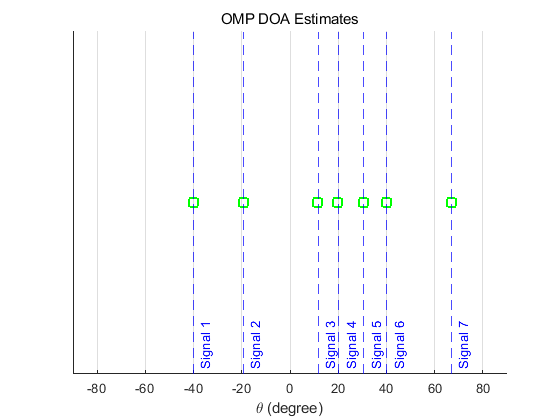

In [2]:
thetaplot = -90:0.1:90;
k = length(theta); %sparsity level
A = steering_vector(thetaplot); %overcomplete dictionary
Lambda = zeros(length(theta),1); %atom set
A_Lambda = []; %matrix of selected atoms
R = X; %initialization of residual matrix
for i=1:k
    W = A'*R; %compute the correlation between atoms and residual
    [~,I] = max(sum(abs(W).^2,2)); %find the index of the atom with maximum correlation
    Lambda(i) = I; %add the atom to the atom set

    A_Lambda = A(:,Lambda(1:i)); %update the matrix of selected atoms
    X_proj = pinv(A_Lambda) * X; %update the coefficient matrix
    R = X - A_Lambda * X_proj; %update the residual matrix
end
theta_est = thetaplot(Lambda); %estimated DOAs
angles_omp = sort(theta_est);
disp('OMP estimated angles (degrees):');
disp(angles_omp(:).');
rmse_omp = sqrt(mean((angles_omp(:).' - sort(theta(:).')).^2));
fprintf('True angles (degrees):\n');
disp(sort(theta(:).'));
fprintf('OMP RMSE = %.6f degrees\n', rmse_omp);

figure;
hold on;
plot(angles_omp, zeros(size(angles_omp)), 'gs', 'MarkerSize', 8, 'LineWidth', 1.5);
grid on;
xlim([-90 90]);
ylim([-1 1]);
for ii = 1:numel(theta)
    xline(theta(ii), 'b--', sprintf('Signal %d', ii), ...
        'LineWidth', 1.2, 'LabelVerticalAlignment', 'bottom');
end
xlabel('\theta (degree)');
yticks([]);
title('OMP DOA Estimates');

#### Compressive Sampling Matching Pursuit (CoSaMP)
Despite OMP is easy to implement, it is not accurate when the sources are close in angle. CoSaMP can select multiple atoms in each iteration, and also prune the selected atoms to correct the selected atom set as well as improve the accuracy. For a K-sparse signal, CoSaMP selects 2K atoms in each iteration, and reserve the K atoms with the largest correlation with the current residual.


CoSaMP estimated angles (degrees):
   19.2000   19.4000   19.6000   19.9000   20.1000   20.2000   20.3000

True angles (degrees):
  -40.1000  -19.3000   11.7000   20.2000   30.6000   40.2000   66.8000

CoSaMP RMSE = 33.271996 degrees


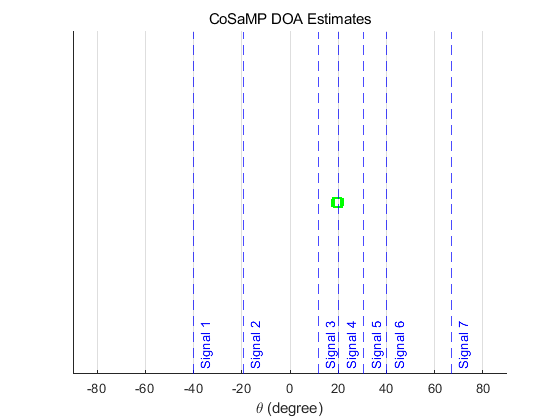

In [3]:
thetaplot = -90:0.1:89.9;
k = length(theta); %sparsity level
A = steering_vector(thetaplot); %overcomplete dictionary
% A = A ./ vecnorm(A,2,1);
Lambda = []; %atom set
A_Lambda = []; %matrix of selected atoms
R = X; %initialization of residual matrix
maxiter = k;
for i=1:maxiter
    W = A'*R; %compute the correlation between atoms and residual
    P = sum(abs(W).^2,2); %compute the correlation power
    [~,I] = sort(P, 'descend'); %find the index of the atom with maximum correlation
    I = I(1:2*k); %select the 2k atoms with the highest correlation
    Lambda = union(Lambda, I); %add the atoms to the atom set

    A_Lambda = A(:,Lambda); %update the matrix of selected atoms
    X_proj = pinv(A_Lambda) * X; %update the coefficient matrix
    [~,I] = sort(sum(abs(X_proj).^2,2), 'descend'); %find the indices of the k largest coefficients
    I = I(1:k); %select the k largest coefficients
    Lambda = Lambda(I); %prune the atom set
    A_Lambda = A(:,Lambda); %update the matrix of selected atoms
    X_proj = pinv(A_Lambda) * X; %update the coefficient matrix
    R = X - A_Lambda * X_proj; %update the residual matrix

end
theta_est = thetaplot(Lambda); %estimated DOAs
angles_cosamp = sort(theta_est);
disp('CoSaMP estimated angles (degrees):');
disp(angles_cosamp(:).');
rmse_cosamp = sqrt(mean((angles_cosamp(:).' - sort(theta(:).')).^2));
fprintf('True angles (degrees):\n');
disp(sort(theta(:).'));
fprintf('CoSaMP RMSE = %.6f degrees\n', rmse_cosamp);

figure;
hold on;
plot(angles_cosamp, zeros(size(angles_cosamp)), 'gs', 'MarkerSize', 8, 'LineWidth', 1.5);
grid on;
xlim([-90 90]);
ylim([-1 1]);
for ii = 1:numel(theta)
    xline(theta(ii), 'b--', sprintf('Signal %d', ii), ...
        'LineWidth', 1.2, 'LabelVerticalAlignment', 'bottom');
end
xlabel('\theta (degree)');
yticks([]);
title('CoSaMP DOA Estimates');

When the number of array elements is 12, OMP and CoSaMP perform both badly, because the aperture of the array is very limited and basically OMP and CoSaMP are iteratively doing conventional beamforming, which highly relies on the aperture of the array. When the number of array elements is 16, OMP performs well. But CoSaMP still performs badly, because the selected atoms gather around the same angle, which leads to a high correlation between the selected atoms, and thus the projection of the observed signal onto the subspace spanned by the selected atoms is not accurate. That is because $\mathbf{A}$ is highly coherent.(Maybe)


### $\ell_{2,1}$ optimization
In multi-snapshot scenarios, we should make full use of the information of all snapshots, so different from the LASSO problem in CS problem, we use the $\ell_{2,1}$ norm to enforce the sparsity of atoms. We define the $\ell_{2,1}$ norm of a matrix $\mathbf{X}$ as:
$$
\| \mathbf{X} \|_{2,1} = \sum_i \|\mathbf{X}_{i,:}\|_2
$$
$\ell_{2,1}$ norm convert the matrix into a vector, whose elements are the $\ell_2$ norms of the rows of the matrix, then apply $\ell_1$ norm to the vector to enforce sparsity, which corresponds to the LASSO problem. Also, the least square term in LASSO problem can be naturally extended to square of Frobenius norm for the multi-snapshot case. So the $\ell_{2,1}$ optimization problem can be formulated as:
$$
\min_{\mathbf{X}} \frac{1}{2} \|\mathbf{Y} - \mathbf{A}\mathbf{X}\|_F^2 + \lambda \|\mathbf{X}\|_{2,1}
$$
which is called group LASSO.

For group LASSO problem, which is a convex problem, we introduce 2 widely used optimization algorithms: the **Fast iterative shrinkage-thresholding algorithm (FISTA)** and the **Alternating Direction Method of Multipliers (ADMM)**. 
#### FISTA
FISTA is an advanced proximal gradient algorithm that accelerates the convergence of the basic iterative shrinkage-thresholding algorithm (ISTA) by incorporating a momentum term. A typical problem it solves is of the form:
$$
\min_{\mathbf{x}} g(\mathbf{x})+h(\mathbf{x}),
$$
where $f(\mathbf{x})$ is a smooth convex function with a Lipschitz continuous gradient, and $g(\mathbf{x})$ is a convex but possibly non-smooth function. The term $g(\mathbf{x})$ often represents the regularization term, and we can not directly compute its derivative, like a box constraint or a sparsity-regularization term. Therefore, we can split the problem into a smooth part $f(\mathbf{x})$ and a non-smooth part $g(\mathbf{x})$, and handle the non-smooth part using its proximal operator. 

Before introduce FISTA, we first take a look at a basic concept called Lipschitz continuous. 
A function $f({x})$ is said to have a Lipschitz continuous gradient with constant $L$ if:
$$
\lvert f({x}) - f({y})\rvert \leq L \lvert {x} - {y}\rvert, \quad \forall {x}, {y}.
$$
This means that the gradient of $f$ has a supremum bounded by $L$, i.e.,
$$
\lvert f^{\prime}({x})\rvert \leq L, \quad \forall {x}.
$$
This can be proved by using Lagrange mean value theorem.

So the aim of this problem is to minimize $f(\mathbf{x}) = g(\mathbf{x})+h(\mathbf{x})$, the proximal gradient method tells us to iteratively update $\mathbf{x}$ by 
$$
\mathbf{x}_{t+1} = \operatorname{prox}_{\alpha_t g} \left( \mathbf{x}_t - \alpha_t \nabla h(\mathbf{x}_t) \right)
$$
where $\operatorname{prox}_{\alpha_t g}$ is the proximal operator of the function $g$ with parameter $\alpha_t$, and $\alpha_t$ is the step size at iteration $t$. 
$\operatorname{prox}$ indicates solving an optimization problem of the form:
$$
\operatorname{prox}_{\alpha g}(\mathbf{v}) = \arg\min_{\mathbf{x}} \left( g(\mathbf{x}) + \frac{1}{2\alpha} \|\mathbf{x} - \mathbf{v}\|^2 \right).
$$

In LASSO problem, first consider the soomth term $g(\mathbf{x})=\frac{1}{2}\|\mathbf{y}-\mathbf{A}\mathbf{x}\|^2$. The derivative is $\mathbf{A}^H (\mathbf{A}\mathbf{x} - \mathbf{y})$, which is Lipschitz continous with constant $L = \|\mathbf{A}^H \mathbf{A}\|_2$, where $\|\cdot\|_2$ denotes the largest singlar value of the matrix, also the largest eigenvalue of the Gram matrix $\mathbf{A}^H \mathbf{A}$.

Thus, the step size $\alpha_t$ is often chosen as the reciprocal of the Lipschitz constant. In many cases, we cannot get the Lipschitz constant easily. For example, the closed form of Lipschitz constant is hard to obtain, or in LASSO problem the measurement matrix $\mathbf{A}$ is large, making the computation of the largest singular value expensive. In such cases, we can apply a backtracking line search to adjust the step size, or for LASSO problem we can use Lanczos algorithm to approximate the largest singular value efficiently.

After we set $\alpha_t = \frac{1}{L}$, define $\mathbf{v}_t = \mathbf{x}_t - \alpha_t \nabla h(\mathbf{x}_t)$. According to the proximal gradient method above, the update of $\mathbf{x}$ can be written as:
$$
\mathbf{x}_{t+1} = \operatorname{prox}_{\alpha_t g} (\mathbf{v}_t).
$$
For LASSO problem, the porximal gradient operator has a closed-form solution known as the soft-thresholding operator:
$$
\operatorname{prox}_{\alpha_t g} (\mathbf{v}_t) = \text{sign}(\mathbf{v}_t) \odot \max\left( |\mathbf{v}_t| - \alpha_t \lambda, 0 \right),
$$
where $\odot$ denotes element-wise multiplication, and the maximum is taken element-wise. That is iteratively soft-thresholding algorithm (ISTA).
FISTA uses Nesterov's acceleration technique to improve the convergence rate of ISTA. It introduces a momentum term that combines the previous two iterates to update the current iterate, leading to faster convergence in practice, which is 
$$
\begin{cases}
\mathbf{z}_{t} = \beta_k(\mathbf{x}_t-\mathbf{x}_{t-1}) \\
\beta_k = \frac{t_k-1}{t_{k+1}} \\
t_{k+1} = \frac{1+\sqrt{1+4t_k^2}}{2} \\
\mathbf{v}_t = \mathbf{z}_t - \frac{1}{L} \mathbf{A}^H (\mathbf{A}\mathbf{z}_t - \mathbf{y}) \\
\mathbf{x}_{t+1} = \operatorname{prox}_{\frac{1}{L} \lambda\|\cdot\|_1} (\mathbf{v}_t) \\
\end{cases}
$$
In group-LASSO problem, the biggest difference is the solution of proximal gradient operator introduced by $\| \cdot \|_{2,1}$. Here we directly given the update rule 
of group-LASSO
$$
\begin{cases}
\mathbf{Z}_{t} = \beta_k(\mathbf{X}_t-\mathbf{X}_{t-1}) \\
\beta_k = \frac{t_k-1}{t_{k+1}} \\
t_{k+1} = \frac{1+\sqrt{1+4t_k^2}}{2} \\
\mathbf{V}_t = \mathbf{Z}_t - \frac{1}{L} \mathbf{A}^H (\mathbf{A}\mathbf{Z}_t - \mathbf{Y}) \\
\mathbf{X}_{t+1} = \operatorname{prox}_{\frac{1}{L} \lambda\|\cdot\|_{2,1}} (\mathbf{V}_t) \\
\end{cases}
$$
where,
$$
\begin{aligned}
\mathbf{X}_{t+1} &= \operatorname{prox}_{\frac{1}{L} \lambda\|\cdot\|_{2,1}} (\mathbf{V}_t) \\
&= \left( 1 - \frac{\frac{\lambda}{L}}{\|\mathbf{V}_t^{(i)}\|_2} \right)_+ (\mathbf{V}_{t})_{i,:}
\end{aligned}
$$
For initialization $\mathbf{Z}_0 = \mathbf{X}_0 = \mathbf{0}, \; t_0 = 1$. 

Introducing Nesterov momentum can make the objective function value oscillate. Therefore, we can use restart strategy which resets the momentum when the accumulated momentum becomes counterproductive, typically when the objective function increases or the gradient direction goes up.
$$
m_k = \operatorname{Re}\langle \mathbf{Z}_t - \mathbf{X}_{t+1}, \mathbf{X}_{t+1}-  \mathbf{X}_{t} \rangle_F
$$
where $\langle B, C \rangle_F$ denotes $\operatorname{tr}(B^H C)$, the Frobenius inner product.
When $m_k>0$, we reset the momentum by let $t_{k+1} = 1$ and $\mathbf{Z}_{t+1} = \mathbf{X}_{t+1}$.

When $\mathbf{X}$ meets the convergence criterion, here we can define it as the residual between the current $\mathbf{X}$ and its proximal gradient.
$$
G_\alpha(\mathbf{X}) = \frac{\mathbf{X} - \operatorname{prox}_{\alpha g} (\mathbf{X} - \alpha \nabla f(\mathbf{X}))}{\alpha}
$$
when $\|G_\alpha(\mathbf{X})\|_F < \epsilon$, where $\epsilon$ is a small positive threshold, we consider the algorithm to have converged.


FISTA estimated top-k angles (degrees):
  -39.9000  -19.3000   11.7000   20.3000   30.3000   40.1000   66.6000

True angles (degrees):
  -40.1000  -19.3000   11.7000   20.2000   30.6000   40.2000   66.8000

FISTA RMSE = 0.164751 degrees


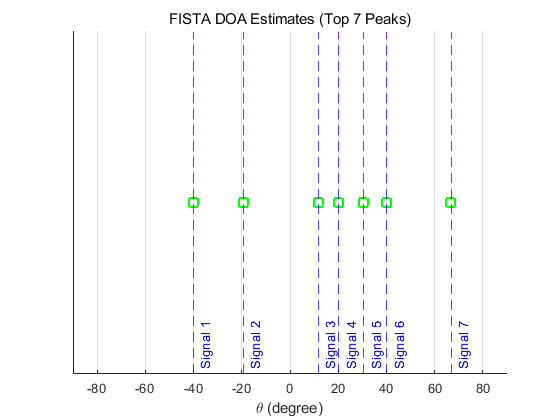

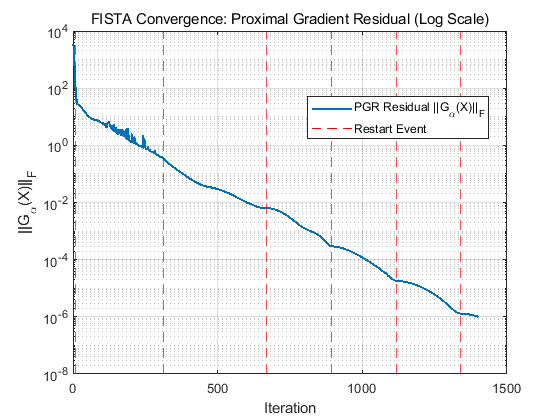

In [4]:
thetaplot = -90:0.1:89.9;
k = length(theta); % sparsity level
A = steering_vector(thetaplot); % overcomplete dictionary
A = A ./ vecnorm(A, 2, 1);
Y = Y_observed; % observed data matrix
C = A' * Y;
lambda_max = max(vecnorm(C, 2, 2));

alpha = 0.01; % recommended range: 0.001 - 0.1
lambda = alpha * lambda_max;
lip = norm(A * A', 2);
step_size = 1 / lip;
maxiter = 2000;
epsilon = 1e-6; % convergence threshold
userestart = true;

[X, res_norm, restart_iters, actual_iters] = solve_group_lasso_fista( ...
    A, Y, C, lambda, step_size, maxiter, epsilon, userestart);

x_norm = vecnorm(X, 2, 2).^2 / num_snapshots;

% Extract top-k DOA angles using peak detection
[~, locs] = findpeaks(x_norm(:).', thetaplot, ...
    'SortStr', 'descend', 'NPeaks', k, ...
    'MinPeakDistance', 1);

% Supplement with remaining highest-energy points if fewer than k peaks are found
if numel(locs) < k
    [~, sort_idx] = sort(x_norm, 'descend');
    remaining = thetaplot(sort_idx);
    remaining(ismember(remaining, locs)) = [];
    locs = [locs, remaining(1:(k - numel(locs)))];
end

angles_fista = sort(locs(:).');

disp('FISTA estimated top-k angles (degrees):');
disp(angles_fista);
fprintf('True angles (degrees):\n');
disp(sort(theta(:).'));

rmse_fista = sqrt(mean((angles_fista - sort(theta(:).')).^2));
fprintf('FISTA RMSE = %.6f degrees\n', rmse_fista);

% Plot DOA estimates
figure;
hold on;
plot(angles_fista, zeros(size(angles_fista)), 'gs', 'MarkerSize', 8, 'LineWidth', 1.5);
grid on;
xlim([-90 90]);
ylim([-1 1]);
for ii = 1:numel(theta)
    xline(theta(ii), 'b--', sprintf('Signal %d', ii), ...
        'LineWidth', 1.2, 'LabelVerticalAlignment', 'bottom');
end
xlabel('\theta (degree)');
yticks([]);
title(sprintf('FISTA DOA Estimates (Top %d Peaks)', k));

% Plot FISTA convergence curve (Proximal Gradient Residual) with restart markers
figure;
h_res = semilogy(1:numel(res_norm), res_norm, 'LineWidth', 1.5, 'Color', [0 0.447 0.741]);
hold on;
grid on;
for ii = 1:numel(restart_iters)
    xline(restart_iters(ii), 'r--', 'LineWidth', 1.2);
end
xlabel('Iteration');
ylabel('||G_\alpha(X)||_F');
title('FISTA Convergence: Proximal Gradient Residual (Log Scale)');

% Add dummy line for restart marker in legend if restarts occurred
if ~isempty(restart_iters)
    h_rst = plot(NaN, NaN, 'r--', 'LineWidth', 1.2);
    legend([h_res, h_rst], {'PGR Residual ||G_\alpha(X)||_F', 'Restart Event'}, 'Location', 'best');
else
    legend(h_res, {'PGR Residual ||G_\alpha(X)||_F'}, 'Location', 'best');
end


#### Alternative Direction Method of Multipliers (ADMM)
A standard form of the ADMM problem is 
$$
\min_x f(x) + g(z) \quad \text{subject to} \quad Ax + Bz = c
$$
By applying augmented Lagrangian techniques, we have
$$
\mathcal{L}_\rho(x, z, y) = f(x) + g(z) + y^\top (Ax + Bz - c) + \frac{\rho}{2} \|Ax + Bz - c\|_2^2
$$
where $\rho > 0$ is the penalty parameter.
ADMM alternatively updates the variables $x$, $z$, and the dual variable $y$ as follows:
$$
\begin{aligned}
x^{k+1} &= \arg\min_x \mathcal{L}_\rho(x, z^k, y^k), \\
z^{k+1} &= \arg\min_z \mathcal{L}_\rho(x^{k+1}, z, y^k), \\
y^{k+1} &= y^k + \rho (Ax^{k+1} + Bz^{k+1} - c).
\end{aligned}
$$
In ADMM, we often introduce a scaled dual variable $u = y / \rho$, consider the last 2 terms of the augmented Lagrangian.
$$
\begin{aligned}
\frac{y^{k+1}}{\rho} &= \frac{y^k}{\rho} + (Ax^{k+1} + Bz^{k+1} - c), \\
u^{k+1} &= u^k + Ax^{k+1} + Bz^{k+1} - c.
\end{aligned}
$$
In LASSO problem, the objective function is 
$$
\min_x \frac{1}{2} \|\mathbf{A}\mathbf{x} - \mathbf{y}\|_2^2 + \lambda \|\mathbf{x}\|_1
$$
which is a unconstrained optimization problem. To convert it into a standard form suitable for ADMM, we introduce an auxiliary variable $\mathbf{z}$ and rewrite the problem as
$$
\begin{cases}
\min_{\mathbf{x}} \frac{1}{2} \|\mathbf{A}\mathbf{x} - \mathbf{y}\|_2^2 + \lambda \|\mathbf{z}\|_1 \\
\text{s.t.} \quad \mathbf{x} - \mathbf{z} = 0
\end{cases}
$$
so $c=0, A=I, B=-I$. Then the update rule for LASSO problem using ADMM is
$$
\begin{aligned}
\mathbf{x}^{k+1} &= \arg\min_{\mathbf{x}} \frac{1}{2} \|\mathbf{A}\mathbf{x} - \mathbf{y}\|_2^2 + \frac{\rho}{2} \|\mathbf{x} - \mathbf{z}^k + \mathbf{u}^k\|_2^2, \\
\mathbf{z}^{k+1} &= \arg\min_{\mathbf{z}} \lambda \|\mathbf{z}\|_1 + \frac{\rho}{2} \|\mathbf{x}^{k+1} - \mathbf{z} + \mathbf{u}^k\|_2^2, \\
\mathbf{u}^{k+1} &= \mathbf{u}^k + \mathbf{x}^{k+1} - \mathbf{z}^{k+1}.
\end{aligned}
$$
Consider the first equation, we can easily derive the closed-form solution by setting the gradient to zero:
$$
\mathbf{A}^H (\mathbf{A}\mathbf{x}^{k+1} - \mathbf{y}) + \rho (\mathbf{x}^{k+1} - \mathbf{z}^k + \mathbf{u}^k) = 0,
$$
which gives
$$
\mathbf{x}^{k+1} = (\mathbf{A}^H \mathbf{A} + \rho \mathbf{I})^{-1} (\mathbf{A}^H \mathbf{y} + \rho (\mathbf{z}^k - \mathbf{u}^k)).
$$
Consider the second equation, this the definition of the proximal operator of the $\ell_1$ norm, so the closed-form solution is given by the soft-thresholding operator:
$$
\mathbf{z}^{k+1} = S_{\lambda / \rho} (\mathbf{x}^{k+1} + \mathbf{u}^k),
$$
Thus we have the complete set of update rules for solving the LASSO problem using ADMM as 
$$
\begin{aligned}
\mathbf{x}^{k+1} &= (\mathbf{A}^H \mathbf{A} + \rho \mathbf{I})^{-1} (\mathbf{A}^H \mathbf{y} + \rho (\mathbf{z}^k - \mathbf{u}^k)), \\
\mathbf{z}^{k+1} &= S_{\lambda / \rho} (\mathbf{x}^{k+1} + \mathbf{u}^k), \\
\mathbf{u}^{k+1} &= \mathbf{u}^k + \mathbf{x}^{k+1} - \mathbf{z}^{k+1}
\end{aligned}
$$
For group LASSO, we can just use the proximal gradient operator of $\ell_{2,1}$ norm

The stop criterion for the ADMM algorithm is typically based on the primal and dual residuals. Specifically, we stop the iterations when
$$
\begin{aligned}
\| \mathbf{x}^{k+1} - \mathbf{z}^{k+1} \|_2 &\leq \epsilon_\text{pri}, \\
\| \rho (\mathbf{z}^{k+1} - \mathbf{z}^k) \|_2 &\leq \epsilon_\text{dual},
\end{aligned}
$$
where 
$$
\begin{aligned}
\epsilon_\text{pri} &= \sqrt{n} \, \epsilon_\text{abs} + \epsilon_\text{rel} \max\{\|\mathbf{x}^{k+1}\|_2, \|\mathbf{z}^{k+1}\|_2\}, \\
\epsilon_\text{dual} &= \sqrt{n} \, \epsilon_\text{abs} + \epsilon_\text{rel} \|\rho \mathbf{u}^{k+1}\|_2
\end{aligned}
$$
where 
$n$
is the dimension of $\mathbf{x}$, 
$\epsilon_\text{abs}$ and $\epsilon_\text{rel}$ are the absolute and relative tolerances, respectively. For group LASSO, we can just use the same stop criterion with $\|\cdot\|_F$ norm instead of the $\ell_2$ norm.

Also we can use a trick to lower the computation cost by precomputing the Gram matrix $\mathbf{A}^H \mathbf{A}$. Usually the number of snapshots is much higher than the which of array elements, which means $\mathbf{A} \in \mathbb{C}^{M \times N}$ with $N \gg M$. Thus the Gram matrix can be very large, leading to high computational cost when solving the linear equation
$$
(\mathbf{A}^H \mathbf{A} + \rho \mathbf{I})\mathbf{x}^{k+1} = \mathbf{A}^H \mathbf{y} + \rho (\mathbf{z}^k - \mathbf{u}^k),
$$
We may as well ignore the superscript $k$ and $k+1$ for simplicity, and define $\mathbf{q} = \mathbf{z} - \mathbf{u}$. Suppose $\mathbf{x} = \mathbf{q} + \Delta$, then the linear equation becomes
$$
\begin{aligned}
(\mathbf{A}^H \mathbf{A} + \rho \mathbf{I})(\mathbf{q}+\Delta) &= \mathbf{A}^H \mathbf{y} + \rho \mathbf{q} \\
(\mathbf{A}^H \mathbf{A} + \rho \mathbf{I})\Delta &= \mathbf{A}^H \mathbf{y} + \rho \mathbf{q} - (\mathbf{A}^H \mathbf{A} + \rho \mathbf{I})\mathbf{q} \\
(\mathbf{A}^H \mathbf{A} + \rho \mathbf{I})\Delta &= \mathbf{A}^H (\mathbf{y} - \mathbf{A} \mathbf{q}) \\
\Delta &= (\mathbf{A}^H \mathbf{A} + \rho \mathbf{I})^{-1} \mathbf{A}^H (\mathbf{y} - \mathbf{A} \mathbf{q}) \\
\end{aligned}
$$
Notice that 
$$
(\mathbf{A}^H \mathbf{A} + \rho \mathbf{I})^{-1} \mathbf{A}^H = \mathbf{A}^H (\mathbf{A} \mathbf{A}^H + \rho \mathbf{I})^{-1}
$$
Thus $\Delta$ can be computed as
$$
\Delta = \mathbf{A}^H (\mathbf{A} \mathbf{A}^H + \rho \mathbf{I})^{-1} (\mathbf{y} - \mathbf{A} \mathbf{q})
$$
Thus we avoid directly compute the Gram matrix and solve a potentially large linear system.

ADMM estimated top-k angles (degrees):
  -39.9000  -19.3000   11.6000   20.4000   30.4000   40.2000   66.5000

True angles (degrees):
  -40.1000  -19.3000   11.7000   20.2000   30.6000   40.2000   66.8000

ADMM RMSE = 0.177281 degrees


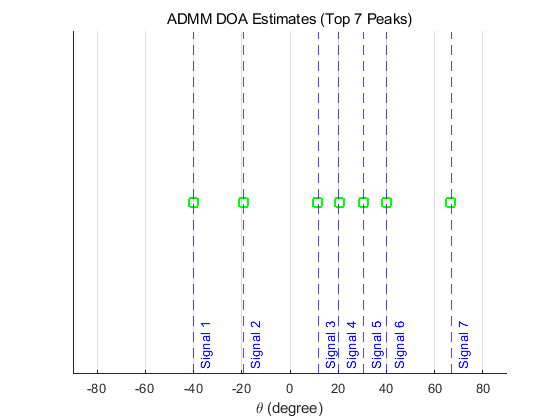

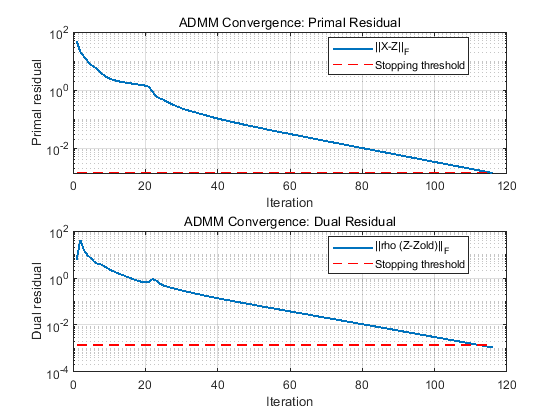

In [5]:
thetaplot = -90:0.1:89.9;
k = length(theta); % sparsity level
A = steering_vector(thetaplot); % overcomplete dictionary
A = A ./ vecnorm(A, 2, 1);
Y = Y_observed; % observed data matrix
C = A' * Y;
lambda_max = max(vecnorm(C, 2, 2));

alpha = 0.01; % recommended range: 0.001 - 0.1
lambda = alpha * lambda_max;

maxiter = 2000;
epsilon_abs = 1e-6; % convergence threshold
epsilon_rel = 1e-6; % relative convergence threshold
rho = 1; % ADMM penalty parameter
[X, r_history, s_history, eps_pri_history, eps_dual_history, actual_iters] = ...
    solve_group_lasso_admm(A, Y, lambda, rho, maxiter, epsilon_abs, epsilon_rel);

% Extract top-k DOA angles using peak detection
[~, locs] = findpeaks(vecnorm(X, 2, 2).', thetaplot, ...
    'SortStr', 'descend', 'NPeaks', k, ...
    'MinPeakDistance', 1);

% Supplement with remaining highest-energy points if fewer than k peaks are found
if numel(locs) < k
    [~, sort_idx] = sort(vecnorm(X, 2, 2), 'descend');
    remaining = thetaplot(sort_idx);
    remaining(ismember(remaining, locs)) = [];
    locs = [locs, remaining(1:(k - numel(locs)))];
end

angles_admm = sort(locs(:).');

disp('ADMM estimated top-k angles (degrees):');
disp(angles_admm);
fprintf('True angles (degrees):\n');
disp(sort(theta(:).'));

rmse_admm = sqrt(mean((angles_admm - sort(theta(:).')).^2));
fprintf('ADMM RMSE = %.6f degrees\n', rmse_admm);

% Plot DOA estimates
figure;
hold on;
plot(angles_admm, zeros(size(angles_admm)), 'gs', 'MarkerSize', 8, 'LineWidth', 1.5);
grid on;
xlim([-90 90]);
ylim([-1 1]);
for ii = 1:numel(theta)
    xline(theta(ii), 'b--', sprintf('Signal %d', ii), ...
        'LineWidth', 1.2, 'LabelVerticalAlignment', 'bottom');
end
xlabel('\theta (degree)');
yticks([]);
title(sprintf('ADMM DOA Estimates (Top %d Peaks)', k));

% Plot ADMM residuals and stopping thresholds
figure;
subplot(2, 1, 1);
semilogy(1:actual_iters, r_history, 'LineWidth', 1.5);
hold on;
semilogy(1:actual_iters, eps_pri_history, 'r--', 'LineWidth', 1.2);
grid on;
xlabel('Iteration');
ylabel('Primal residual');
title('ADMM Convergence: Primal Residual');
legend({'||X-Z||_F', 'Stopping threshold'}, 'Location', 'best');

subplot(2, 1, 2);
semilogy(1:actual_iters, s_history, 'LineWidth', 1.5);
hold on;
semilogy(1:actual_iters, eps_dual_history, 'r--', 'LineWidth', 1.2);
grid on;
xlabel('Iteration');
ylabel('Dual residual');
title('ADMM Convergence: Dual Residual');
legend({'||rho (Z-Zold)||_F', 'Stopping threshold'}, 'Location', 'best');


#### $\ell_{1}-SVD$ 
When the number of snapshots is too large, the matrix can be oversize so that the computational cost becomes burdensome. So here is a method called $\ell_{1}-SVD$ which leverages the singular value decomposition (SVD) to reduce the dimensionality of the problem while preserving the essential information for sparse recovery.

The idea is quite simple. We apply SVD to the observed data matrix and retain only the leading singular vectors corresponding to the largest singular values or the non-zero singular values. After applying SVD, we have 
$$
\mathbf{Y} = \mathbf{U} \mathbf{\Sigma} \mathbf{V}^H
$$
where $\mathbf{U}$ contains the left singular vectors, $\mathbf{\Sigma}$ is a diagonal matrix with the singular values, and $\mathbf{V}$ contains the right singular vectors. By retaining signal subspace, we can form a reduced-dimension data matrix
$$
\mathbf{Y}_{K} = \mathbf{Y}\mathbf{V}_{K}
$$
Then construct corresponding $\mathbf{X}_{K}$ and LASSO problem

FISTA estimated top-k angles (degrees):
  -40.1000  -19.3000   11.7000   20.2000   30.5000   40.1000   66.8000

True angles (degrees):
  -40.1000  -19.3000   11.7000   20.2000   30.6000   40.2000   66.8000

FISTA RMSE = 0.053452 degrees


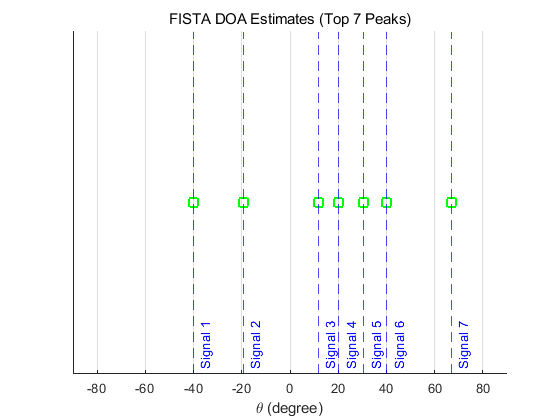

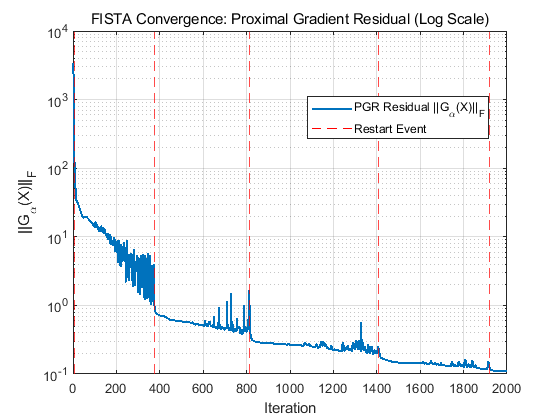

ADMM-SVD estimated top-k angles (degrees):
  -40.1000  -19.3000   11.7000   20.2000   30.5000   40.1000   66.8000

True angles (degrees):
  -40.1000  -19.3000   11.7000   20.2000   30.6000   40.2000   66.8000

ADMM-SVD RMSE = 0.053452 degrees


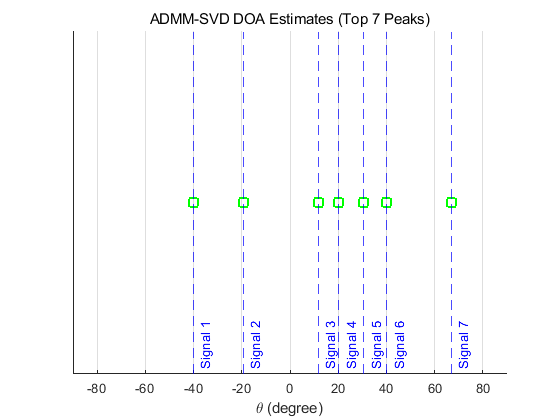

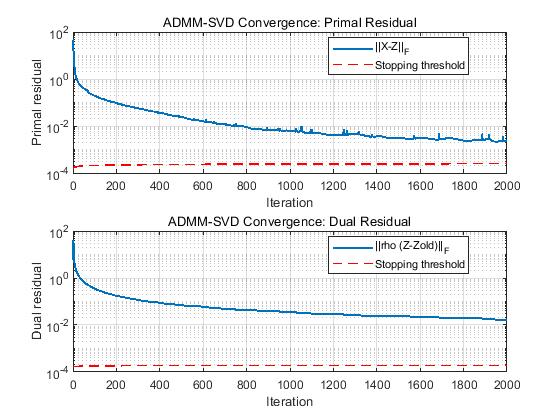

In [6]:
thetaplot = -90:0.1:89.9;
k = length(theta); % sparsity level
A = steering_vector(thetaplot); % overcomplete dictionary
A = A ./ vecnorm(A, 2, 1);
Y = Y_observed; % observed data matrix
[U,Sigma,V] = svd(Y, 'econ');
Vk = V(:, 1:k);
% Vk = V; %retain all the right singular vectors with non-zero singular values
Y_k = Y * Vk;
C = A' * Y_k;
lambda_max = max(vecnorm(C, 2, 2));

alpha = 0.01; % recommended range: 0.001 - 0.1
lambda = alpha * lambda_max;
lip = norm(A * A', 2);
step_size = 1 / lip;
maxiter = 2000;
epsilon = 1e-6; % convergence threshold
userestart = true;

[X, res_norm, restart_iters, actual_iters] = solve_group_lasso_fista( ...
    A, Y_k, C, lambda, step_size, maxiter, epsilon, userestart);

x_norm = vecnorm(X, 2, 2).^2 / size(Y_k, 2);

% Extract top-k DOA angles using peak detection
[~, locs] = findpeaks(x_norm(:).', thetaplot, ...
    'SortStr', 'descend', 'NPeaks', k, ...
    'MinPeakDistance', 1);

% Supplement with remaining highest-energy points if fewer than k peaks are found
if numel(locs) < k
    [~, sort_idx] = sort(x_norm, 'descend');
    remaining = thetaplot(sort_idx);
    remaining(ismember(remaining, locs)) = [];
    locs = [locs, remaining(1:(k - numel(locs)))];
end

angles_fista = sort(locs(:).');

disp('FISTA estimated top-k angles (degrees):');
disp(angles_fista);
fprintf('True angles (degrees):\n');
disp(sort(theta(:).'));

rmse_fista = sqrt(mean((angles_fista - sort(theta(:).')).^2));
fprintf('FISTA RMSE = %.6f degrees\n', rmse_fista);

% Plot DOA estimates
figure;
hold on;
plot(angles_fista, zeros(size(angles_fista)), 'gs', 'MarkerSize', 8, 'LineWidth', 1.5);
grid on;
xlim([-90 90]);
ylim([-1 1]);
for ii = 1:numel(theta)
    xline(theta(ii), 'b--', sprintf('Signal %d', ii), ...
        'LineWidth', 1.2, 'LabelVerticalAlignment', 'bottom');
end
xlabel('\theta (degree)');
yticks([]);
title(sprintf('FISTA DOA Estimates (Top %d Peaks)', k));

% Plot FISTA convergence curve (Proximal Gradient Residual) with restart markers
figure;
h_res = semilogy(1:numel(res_norm), res_norm, 'LineWidth', 1.5, 'Color', [0 0.447 0.741]);
hold on;
grid on;
for ii = 1:numel(restart_iters)
    xline(restart_iters(ii), 'r--', 'LineWidth', 1.2);
end
xlabel('Iteration');
ylabel('||G_\alpha(X)||_F');
title('FISTA Convergence: Proximal Gradient Residual (Log Scale)');

% Add dummy line for restart marker in legend if restarts occurred
if ~isempty(restart_iters)
    h_rst = plot(NaN, NaN, 'r--', 'LineWidth', 1.2);
    legend([h_res, h_rst], {'PGR Residual ||G_\alpha(X)||_F', 'Restart Event'}, 'Location', 'best');
else
    legend(h_res, {'PGR Residual ||G_\alpha(X)||_F'}, 'Location', 'best');
end

% ADMM on the same SVD-reduced observations and regularization parameter
epsilon_abs = 1e-6; % convergence threshold
epsilon_rel = 1e-6; % relative convergence threshold
rho = 1; % ADMM penalty parameter
[X_admm_svd, r_history_admm_svd, s_history_admm_svd, eps_pri_history_admm_svd, eps_dual_history_admm_svd, actual_iters_admm_svd] = ...
    solve_group_lasso_admm(A, Y_k, lambda, rho, maxiter, epsilon_abs, epsilon_rel);

% Extract top-k DOA angles using peak detection
[~, locs] = findpeaks(vecnorm(X_admm_svd, 2, 2).', thetaplot, ...
    'SortStr', 'descend', 'NPeaks', k, ...
    'MinPeakDistance', 1);

% Supplement with remaining highest-energy points if fewer than k peaks are found
if numel(locs) < k
    [~, sort_idx] = sort(vecnorm(X_admm_svd, 2, 2), 'descend');
    remaining = thetaplot(sort_idx);
    remaining(ismember(remaining, locs)) = [];
    locs = [locs, remaining(1:(k - numel(locs)))];
end

angles_admm_svd = sort(locs(:).');

disp('ADMM-SVD estimated top-k angles (degrees):');
disp(angles_admm_svd);
fprintf('True angles (degrees):\n');
disp(sort(theta(:).'));

rmse_admm_svd = sqrt(mean((angles_admm_svd - sort(theta(:).')).^2));
fprintf('ADMM-SVD RMSE = %.6f degrees\n', rmse_admm_svd);

% Plot DOA estimates
figure;
hold on;
plot(angles_admm_svd, zeros(size(angles_admm_svd)), 'gs', 'MarkerSize', 8, 'LineWidth', 1.5);
grid on;
xlim([-90 90]);
ylim([-1 1]);
for ii = 1:numel(theta)
    xline(theta(ii), 'b--', sprintf('Signal %d', ii), ...
        'LineWidth', 1.2, 'LabelVerticalAlignment', 'bottom');
end
xlabel('\theta (degree)');
yticks([]);
title(sprintf('ADMM-SVD DOA Estimates (Top %d Peaks)', k));

% Plot ADMM residuals and stopping thresholds
figure;
subplot(2, 1, 1);
semilogy(1:actual_iters_admm_svd, r_history_admm_svd, 'LineWidth', 1.5);
hold on;
semilogy(1:actual_iters_admm_svd, eps_pri_history_admm_svd, 'r--', 'LineWidth', 1.2);
grid on;
xlabel('Iteration');
ylabel('Primal residual');
title('ADMM-SVD Convergence: Primal Residual');
legend({'||X-Z||_F', 'Stopping threshold'}, 'Location', 'best');

subplot(2, 1, 2);
semilogy(1:actual_iters_admm_svd, s_history_admm_svd, 'LineWidth', 1.5);
hold on;
semilogy(1:actual_iters_admm_svd, eps_dual_history_admm_svd, 'r--', 'LineWidth', 1.2);
grid on;
xlabel('Iteration');
ylabel('Dual residual');
title('ADMM-SVD Convergence: Dual Residual');
legend({'||rho (Z-Zold)||_F', 'Stopping threshold'}, 'Location', 'best');


### $\ell_{2,p}$ Norm
To have a better approximation to $\ell_0$ norm, we can use the $\ell_{2,p}$ norm, defined as
$$
\|X\|_{2,p} = \left( \sum_i \|X_{i,:}\|_2^p \right)^{1/p},
$$
where $0 < p \le 1$. $\ell_{p}$ norm is defined as
$$
\|x\|_p = \left( \sum_i |x_i|^p \right)^{1/p}.
$$
A $\ell_{2,p}$ problem has the same form as group-LASSO problem 
$$
\min_X  \frac{1}{2}\|\mathbf{Y} - \mathbf{A}\mathbf{X}\|_F^2 + \lambda \|\mathbf{X}\|_{2,p}^p,
$$
This is a non-convex optimization problem for $0 < p < 1$. But there are some tricks to solve it.

<!-- First, let us separate the $\ell_{2,p}$ norm as 
$$
|\|X\|_{2,p}^p = \sum_i \|X_{i,:}\|_2^p = \sum_i (\|X_{i,:}\|_2^{p-2}) \|X_{i,:}\|_2^2 = \sum_i w_i \|X_{i,:}\|_2^2,
$$ -->

Consider the $\ell_{2,p}$ norm term $\|\mathbf{X}\|_{2,p}^p = \sum_i \|\mathbf{X}_{i,:}\|_2^p$, define $s = \|\mathbf{X}_{i,:}\|_2^2$, then 
we have a function to derive $\ell_{2,p}$ norm term with respect to $s$, and we often add a small constant $\epsilon$ for stability:
$$
f(s) = (s + \epsilon)^{\frac{p}{2}}
$$
Because $0 < p \le 1$, the function $f(s)$ is concave with respect to $s$, so we can have a supremum based on the first-order Taylor expansion:
$$
f(s) \le f(s_0) + f'(s_0) (s - s_0) = f(s_0)- f'(s_0) s_0 + f'(s_0) s
$$
where $s_0$ is the current estimate of $s$, and $f'(s_0) = \frac{p}{2} (s_0 + \epsilon)^{\frac{p}{2} - 1}$. 
$f(s_0)- f'(s_0) s_0$ will not affect the optimization with respect to $s$, so we can have the weight
$$
w_i = (s_0 + \epsilon)^{\frac{p}{2} - 1}
$$

So the original $\ell_{2,p}$ problem can be approximated by a weighted $\ell_{2}$ problem:
$$
\min_{\mathbf{X}}  \frac{1}{2}\|\mathbf{Y} - \mathbf{A}\mathbf{X}\|_F^2 + \frac{\lambda p}{2} \sum_i w_i \|\mathbf{X}_{i,:}\|_2^2,
$$
where the weights $w_i = (\|\mathbf{X}^{(k-1)}_{i,:}\|_2^2 + \epsilon)^{\frac{p}{2} - 1}$ in the $k$-th iteration. 
<!-- For stability, we can add a small constant $\epsilon$ to avoid division by zero:
$$
w_i = (\|\mathbf{X}_{i,:}\|_2^2 + \epsilon)^{\frac{p-2}{2}}.
$$ -->
Although the weight $w_i$ depends on $\mathbf{X}$, we can use an iterative reweighting scheme to solve the problem: we start with an initial for 
$\mathbf{X} = \mathbf{A}^\dagger \mathbf{Y}$, compute the weights $w_i$, solve the weighted $\ell_2$ problem to update $\mathbf{X}$, and repeat until convergence.

For each iteration, we can solve the weighted $\ell_2$ problem by setting the derivative of the objective function with respect to $\mathbf{X}$ to zero, which gives the following closed-form solution.
Setting 
$$
\begin{aligned}
J(\mathbf{X}) &=  \frac{1}{2}\|\mathbf{Y} - \mathbf{A}\mathbf{X}\|_F^2 + \frac{\lambda p}{2} \sum_i w_i \|\mathbf{X}_{i,:}\|_2^2 \\
\frac{\partial J(\mathbf{X})}{\partial \mathbf{X}} 
&= \frac{1}{2}\operatorname{tr}\left((\mathbf{Y} - \mathbf{A}\mathbf{X})^H (\mathbf{Y} - \mathbf{A}\mathbf{X})\right) 
+ \frac{\lambda p}{2} \operatorname{tr}\left( \mathbf{X}^H \mathbf{W} \mathbf{X}\right) \\

&= \mathbf{A}^H (\mathbf{A}\mathbf{X} - \mathbf{Y}) +  \lambda p \mathbf{W} \mathbf{X}
\end{aligned}
$$
Set the derivative to zero to find the optimal $\mathbf{X}$:
$$
\mathbf{A}^H (\mathbf{A}\mathbf{X} - \mathbf{Y}) +  \lambda p \mathbf{W} \mathbf{X} = 0,
$$
which gives the closed-form solution:
$$
\mathbf{X} = (\mathbf{A}^H \mathbf{A} + \lambda p \mathbf{W})^{-1} \mathbf{A}^H \mathbf{Y}.
$$
where $\mathbf{W} = \operatorname{diag}(w_1, w_2, \dots, w_n)$ and $w_i = (\|\mathbf{X}_{i,:}\|_2^2 + \epsilon)^{\frac{p-2}{2}}$.
So in $k$-th interation, we first have 
$$
w_i^{(k)} = (\|\mathbf{X}_{i,:}^{(k-1)}\|_2^2 + \epsilon)^{\frac{p-2}{2}},
$$
and then update $\mathbf{X}$ using the closed-form solution:
$$
\mathbf{X}^{(k)} = (\mathbf{A}^H \mathbf{A} + \lambda p \mathbf{W}^{(k)})^{-1} \mathbf{A}^H \mathbf{Y},
$$

We repeat this process until convergence, i.e., until $\|\mathbf{X}^{(k)} - \mathbf{X}^{(k-1)}\|_F$ is smaller than a predefined threshold.

FOCUSS estimated top-k angles (degrees):
  -39.3000  -20.2000   12.4000   20.4000   30.3000   39.3000   68.9000

True angles (degrees):
  -40.1000  -19.3000   11.7000   20.2000   30.6000   40.2000   66.8000

FOCUSS RMSE = 1.020504 degrees


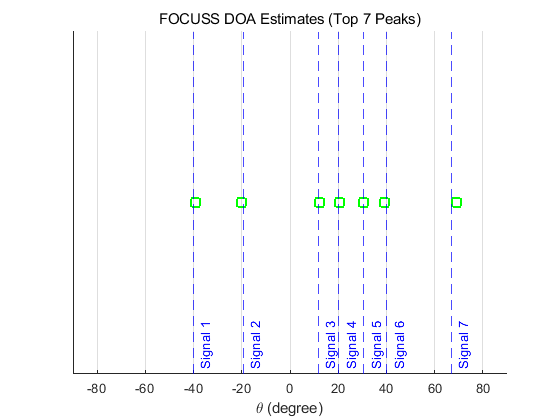

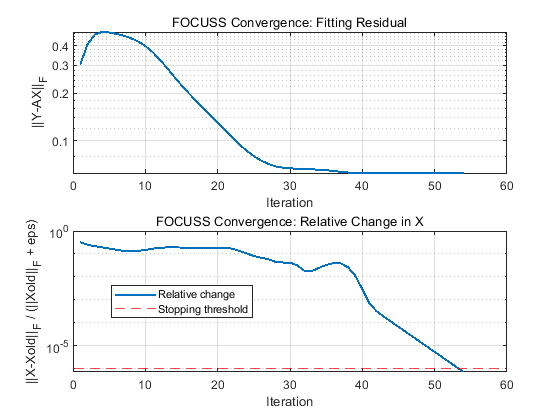

In [7]:
thetaplot = -90:0.1:89.9;
k = length(theta); % sparsity level
A = steering_vector(thetaplot); % overcomplete dictionary
A = A ./ vecnorm(A, 2, 1);
Y = Y_observed; % observed data matrix
Gram = A'*A;
C = A'*Y;
lambda_max = max(vecnorm(Gram, 2, 2));

alpha = 0.01; % recommended range: 0.001 - 0.1
lambda = alpha * lambda_max;

maxiter = 2000;
eta = 1e-6; % convergence threshold
X = pinv(A) * Y;
p = 0.5;
epsilon = eta * (max(vecnorm(X, 2, 2))^2);
stop_threshold = 1e-6; 
[X, fit_history, rel_history, actual_iters] = solve_focuss( ...
    A, Y, X, Gram, C, lambda, p, epsilon, maxiter, stop_threshold);

% Extract top-k DOA angles using peak detection
[~, locs] = findpeaks(vecnorm(X, 2, 2).', thetaplot, ...
    'SortStr', 'descend', 'NPeaks', k, ...
    'MinPeakDistance', 1);

% Supplement with remaining highest-energy points if fewer than k peaks are found
if numel(locs) < k
    [~, sort_idx] = sort(vecnorm(X, 2, 2), 'descend');
    remaining = thetaplot(sort_idx);
    remaining(ismember(remaining, locs)) = [];
    locs = [locs, remaining(1:(k - numel(locs)))];
end

angles_FOCUSS = sort(locs(:).');

disp('FOCUSS estimated top-k angles (degrees):');
disp(angles_FOCUSS);
fprintf('True angles (degrees):\n');
disp(sort(theta(:).'));

rmse_focuss = sqrt(mean((angles_FOCUSS - sort(theta(:).')).^2));
fprintf('FOCUSS RMSE = %.6f degrees\n', rmse_focuss);

% Plot DOA estimates
figure;
hold on;
plot(angles_FOCUSS, zeros(size(angles_FOCUSS)), 'gs', 'MarkerSize', 8, 'LineWidth', 1.5);
grid on;
xlim([-90 90]);
ylim([-1 1]);
for ii = 1:numel(theta)
    xline(theta(ii), 'b--', sprintf('Signal %d', ii), ...
        'LineWidth', 1.2, 'LabelVerticalAlignment', 'bottom');
end
xlabel('\theta (degree)');
yticks([]);
title(sprintf('FOCUSS DOA Estimates (Top %d Peaks)', k));

% Plot FOCUSS fitting residual and relative change in X
figure;
subplot(2, 1, 1);
semilogy(1:actual_iters, fit_history, 'LineWidth', 1.5);
grid on;
xlabel('Iteration');
ylabel('||Y-AX||_F');
title('FOCUSS Convergence: Fitting Residual');

subplot(2, 1, 2);
h_rel = semilogy(1:actual_iters, rel_history, 'LineWidth', 1.5);
hold on;
h_stop = yline(stop_threshold, 'r--', 'LineWidth', 1.2);
grid on;
xlabel('Iteration');
ylabel('||X-Xold||_F / (||Xold||_F + eps)');
title('FOCUSS Convergence: Relative Change in X');
legend([h_rel, h_stop], {'Relative change', 'Stopping threshold'}, 'Location', 'best');


### Sparse Iterative Covariance-based Estimation (SPICE)
Reconsider the far-field narrow band signal model. 
$$
\mathbf{X} = \mathbf{A}(\boldsymbol{\theta})\mathbf{S} + \mathbf{N}
$$
The ideal covariance matrix is 
$$
\mathbf{R} = \mathbb{E}\{\mathbf{X}\mathbf{X}^H\} = \mathbf{A}(\boldsymbol{\theta})\mathbf{P}\mathbf{A}^H(\boldsymbol{\theta}) + \boldsymbol{\sigma}^{\top} \mathbf{I}
$$
Here we consider the noise of each sensor to be potentially different.
We can define another set of parameters 
$$
\begin{cases}
\mathbf{R} = \mathbf{B} \mathbf{Q} \mathbf{B}^H \\
\mathbf{B} = \begin{bmatrix} \mathbf{A}(\boldsymbol{\theta}) & \mathbf{I} \end{bmatrix} \\
\mathbf{Q} = \begin{bmatrix} \mathbf{P} & \mathbf{0} \\ \mathbf{0} & \boldsymbol{\sigma}^{\top} \mathbf{I}\end{bmatrix}
\end{cases}
$$
In practice, we often use the sample covariance matrix to estimate the true covariance matrix:
$$
\widehat{\mathbf{R}} = \frac{1}{L} \mathbf{X} \mathbf{X}^H
$$
In SPICE, we define the covariance matrix for estimating as $\mathbf{R}(\mathbf{p},\boldsymbol{\sigma}) = \mathbf{R}(\mathbf{q})$.
Define the true covariance matrix as 
$$
\widehat{\mathbf{R}} = \mathbf{R} + \mathbf{E}
$$
where $\mathbf{E}$ represents the estimation error between the sample covariance matrix and the true covariance matrix.
We may as well apply vectorization to both sides of the equation
$$
\begin{aligned}
\text{vec}(\widehat{\mathbf{R}}) &= \text{vec}(\mathbf{R}) + \text{vec}(\mathbf{E}) \\
\mathbf{\widehat{r}} &= \mathbf{r} + \mathbf{e} \\
\mathbf{e} &= \mathbf{\widehat{r}} - \mathbf{r}
\end{aligned}
$$
Here $\mathrm{E}\left[\mathbf{e}\right] = \mathbf{0}$, $\operatorname{Cov}\left[\mathbf{e}\right] = \boldsymbol{\Sigma}$
Because elements in $\mathbf{e}$ are not independent, and usually the error of each element has diffrent variance, we consider the generalized least square method, which is given by.
$$
\begin{aligned}
J(\mathbf{q}) = (\mathbf{\widehat{r}} - \mathbf{r}(\mathbf{q}))^H \boldsymbol{\Sigma}^{-1} (\mathbf{\widehat{r}} - \mathbf{r}(\mathbf{q}))^H 
\end{aligned}
$$ 
First we need to obtain the exact form of $\boldsymbol{\Sigma}$.
$$
\begin{aligned}
\boldsymbol{\Sigma} &= \operatorname{Cov}(\mathbf{e},\mathbf{e}) \\
    &=  \mathrm{E}\left[(\mathbf{e}-0)(\mathbf{e}-0)^H \right] \\
    &=  \mathrm{E}\left[(\mathbf{\widehat{r}} - \mathbf{r})(\mathbf{\widehat{r}} - \mathbf{r})^H \right] \\
    &=  \mathrm{E}\left[
        \mathbf{\widehat{r}} \mathbf{\widehat{r}}^H -
        \mathbf{\widehat{r}} \mathbf{r}^H -
        \mathbf{r} \mathbf{\widehat{r}}^H +
        \mathbf{r} \mathbf{r}^H
        \right] \\
    &=  \mathrm{E}\left[
        \mathbf{\widehat{r}} \mathbf{\widehat{r}}^H -
        \mathbf{\widehat{r}} \mathbf{r}^H -
        \mathbf{r} \mathbf{\widehat{r}}^H +
        \mathbf{r} \mathbf{r}^H
        \right] \\
    &=  \mathrm{E}\left[ \mathbf{\widehat{r}} \mathbf{\widehat{r}}^H\right] - 
        \mathrm{E}\left[ \mathbf{\widehat{r}} \right]\mathbf{r}^H - 
        \mathbf{r} \mathrm{E}\left[ \mathbf{\widehat{r}} \right]^H +
        \mathbf{{r}}\mathbf{{r}}^H \\
    &= \mathrm{E}\left[ \mathbf{\widehat{r}} \mathbf{\widehat{r}}^H\right] - \mathbf{{r}}\mathbf{{r}}^H
\end{aligned}
$$
Because $\widehat{\mathbf{R}} = \frac{1}{L}\sum_i^L\mathbf{x}_i\mathbf{x}^H_i$. Suppose $\mathbf{x}_i \sim \mathcal{CN}(\mathbf{0},\mathbf{R})$. Thus,
$$
\begin{aligned} 
\mathrm{E}\left[ \mathbf{\widehat{r}} \mathbf{\widehat{r}}^H\right] 
    &= \mathrm{E}\left[
    \operatorname{vec}(\widehat{\mathbf{R}})\operatorname{vec}(\widehat{\mathbf{R}})^H
    \right] \\
    &= \mathrm{E}\left[
    \operatorname{vec}(\frac{1}{L} \mathbf{X} \mathbf{X}^H)
    \operatorname{vec}(\frac{1}{L} \mathbf{X} \mathbf{X}^H)^H
    \right] \\
    &= \mathrm{E}\left[
    \operatorname{vec}(\frac{1}{L} \sum_i\mathbf{x}_i \mathbf{x}_i^H)
    \operatorname{vec}(\frac{1}{L} \sum_k\mathbf{x}_k \mathbf{x}_k^H)^H
    \right] \\
    &=\frac{1}{L^2}\sum_i\sum_k
    \mathrm{E}\left[\operatorname{vec}(\mathbf{x}_i \mathbf{x}_i^H)\operatorname{vec}(\mathbf{x}_k \mathbf{x}_k^H)^H\right] \\
    &=\frac{1}{L^2}\sum_i\sum_k
    \mathrm{E}\left[(\mathbf{x}_i^* \otimes \mathbf{x}_i)(\mathbf{x}_k^{\top} \otimes \mathbf{x}_k^H)\right] \\
    &=\frac{1}{L^2}\sum_i\sum_k
    \mathrm{E}\left[(\mathbf{x}_i^* \mathbf{x}_k^{\top}) \otimes  (\mathbf{x}_i\mathbf{x}_k^H)\right] \\
    &=\frac{1}{L^2}\sum_i\sum_k
    \mathrm{E}\left[( \mathbf{x}_k\mathbf{x}_i^H)^{\top} \otimes  (\mathbf{x}_i\mathbf{x}_k^H)\right]
\end{aligned}
$$
Let us look at the term inside the expectation $(\mathbf{x}_k\mathbf{x}_i^H)^{\top} \otimes  (\mathbf{x}_i\mathbf{x}_k^H)$
$$
\begin{aligned}
(\mathbf{x}_k\mathbf{x}_i^H)^{\top} \otimes  (\mathbf{x}_i\mathbf{x}_k^H) &=
\left(\begin{bmatrix}x_{1,k} \\\vdots \\x_{M,k}\end{bmatrix}
\begin{bmatrix}x^*_{1,i} &\cdots &x^*_{M,i}\end{bmatrix}\right)^{\top}
\otimes
\left(\begin{bmatrix}x_{1,i} \\\vdots \\x_{M,i}\end{bmatrix}
\begin{bmatrix}x^*_{1,k} &\cdots &x^*_{M,k}\end{bmatrix}\right) \\

&= 
\left(\begin{bmatrix}x^*_{1,i} \\ \vdots \\ x^*_{M,i}\end{bmatrix}
\begin{bmatrix}x_{1,k} & \cdots & x_{M,k}\end{bmatrix}
\right)
\otimes
\left(\begin{bmatrix}x_{1,i} \\\vdots \\x_{M,i}\end{bmatrix}
\begin{bmatrix}x^*_{1,k} &\cdots &x^*_{M,k}\end{bmatrix}\right)


\\
&= 
\begin{bmatrix}
x^*_{1,i}x_{1,k} & x^*_{1,i}x_{2,k} & \cdots & x^*_{1,i}x_{M,k} \\
x^*_{2,i}x_{1,k} & x^*_{2,i}x_{2,k} & \cdots & x^*_{2,i}x_{M,k} \\
\vdots           & \vdots           & \ddots & \vdots \\
x^*_{M,i}x_{1,k} & x^*_{M,i}x_{2,k} & \cdots & x^*_{M,i}x_{M,k} 
\end{bmatrix}
\otimes

\begin{bmatrix}
x_{1,i}x^*_{1,k} & x_{1,i}x^*_{2,k} & \cdots & x_{1,i}x^*_{M,k} \\
x_{2,i}x^*_{1,k} & x_{2,i}x^*_{2,k} & \cdots & x_{2,i}x^*_{M,k} \\
\vdots           & \vdots           & \ddots & \vdots \\
x_{M,i}x^*_{1,k} & x_{M,i}x^*_{2,k} & \cdots & x_{M,i}x^*_{M,k} 
\end{bmatrix}

\end{aligned} 
$$
Each element can be expressed as $x^*_{\alpha,i}x_{\beta,k}x_{m,i}x^*_{n,k}$. After expectation, each element is 
$\mathrm{E}\left[ x^*_{\alpha,i}x_{\beta,k}x_{m,i}x^*_{n,k} \right]$. Therefore, 
$$
\begin{aligned}
\mathrm{E}\left[ x^*_{\alpha,i}x_{\beta,k}x_{m,i}x^*_{n,k} \right] 
&= \mathrm{E}\left[ x_{m,i}x^*_{\alpha,i}x_{\beta,k}x^*_{n,k} \right] \\
&= 
\begin{cases}
\mathrm{E}\left[ x_{m,i}x^*_{\alpha,i}\right]\mathrm{E}\left[ x_{\beta,k}x^*_{n,k}\right] & i \neq k \\
\mathrm{E}\left[ x_{m,i}x^*_{\alpha,i}x_{\beta,i}x^*_{n,i} \right] & i = k
\end{cases} \\
&=
\begin{cases}
R_{m\alpha}R_{\beta n} & i \neq k \\
\mathrm{E}\left[ x_{m,i}x^*_{\alpha,i}\right]\mathrm{E}\left[ x_{\beta,i}x^*_{n,i}\right] +
\mathrm{E}\left[ x_{m,i}x_{\beta,i}\right]\mathrm{E}\left[ x^*_{\alpha,i}x^*_{n,i}\right] +
\mathrm{E}\left[ x_{m,i}x^*_{n,i}\right]\mathrm{E}\left[ x_{\alpha,i}x^*_{\beta,i}\right]
& i = k
\end{cases} \\
\end{aligned}
$$
For $\mathbf{x} \sim \mathcal{CN}(\mathbf{0},\mathbf{R})$, an important property is that 
$\mathrm{E}\left[ \mathbf{x}\mathbf{x}^\top \right] = \mathbf{0}$, which means $\mathrm{E}\left[ x_{m,i}x_{\beta,i}\right] = 0$ and $\mathrm{E}\left[ x^*_{\alpha,i}x^*_{n,i}\right] = 0$. Therefore, we have
$$
\begin{aligned}
\mathrm{E}\left[ x^*_{\alpha,i}x_{\beta,k}x_{m,i}x^*_{n,k} \right] &=
\begin{cases}
R_{m\alpha}R_{\beta n} & i \neq k \\
\mathrm{E}\left[ x_{m,i}x^*_{\alpha,i}\right]\mathrm{E}\left[ x_{\beta,i}x^*_{n,i}\right] +
\mathrm{E}\left[ x_{m,i}x^*_{n,i}\right]\mathrm{E}\left[ x_{\alpha,i}x^*_{\beta,i}\right]
& i = k
\end{cases} \\
&=
\begin{cases}
R_{m\alpha}R_{\beta n} & i \neq k \\
R_{m\alpha}R_{\beta n} +
R_{mn}R_{\alpha\beta}
& i = k
\end{cases} \\
&=
\begin{cases}
R_{m\alpha}R_{\beta n} & i \neq k \\
R_{m\alpha}R_{\beta n} +
R_{mn}R_{\alpha\beta}
& i = k
\end{cases} 
\end{aligned}
$$

Thus for an element in $\mathrm{E}\left[( \mathbf{x}_k\mathbf{x}_i^H)^{\top} \otimes  (\mathbf{x}_i\mathbf{x}_k^H)\right]$, we have
$$
\begin{aligned}
\mathrm{E}\left[( \mathbf{x}_k\mathbf{x}_i^H)^{\top} \otimes  (\mathbf{x}_i\mathbf{x}_k^H)\right]_{(\alpha,m),(\beta,n)} 
&= \mathrm{E}\left[ x^*_{\alpha,i}x_{\beta,k}x_{m,i}x^*_{n,k} \right] \\
&= \begin{cases}
R_{m\alpha}R_{\beta n} & i \neq k \\
R_{m\alpha}R_{\beta n} +
R_{mn}R_{\alpha\beta}
& i = k
\end{cases} \\
\end{aligned}
$$
where $(\alpha,m)$ means the $\alpha$-th blokc row and $m$-th row in that block, and $(\beta,n)$ means the $\beta$-th block column and $n$-th column in that block.

Consider 
$$
\mathbf{r} = \operatorname{vec}(\mathbf{R}) = 
\begin{bmatrix}
R_{11} \\ R_{21} \\ \vdots \\ R_{M1} \\ R_{12} \\ R_{22} \\ \vdots \\ R_{M2} \\ \vdots \\ R_{1M} \\ R_{2M} \\ \vdots \\ R_{MM}
\end{bmatrix}
$$
So we can denote that $\mathbf{r}_{(\alpha,m)} = R_{m\alpha}, \mathbf{r}_{(\beta,n)} = R_{n\beta}$. Thus 
$$
\mathbf{r}\mathbf{r}^H_{(\alpha,m),(\beta,n)} = R_{m\alpha}R^*_{n\beta} = R_{m\alpha}R_{\beta n}
$$
because $\mathbf{R}$ is Hermitian. Therefore, when $i \neq k$, we have
$$
\mathrm{E}\left[( \mathbf{x}_k\mathbf{x}_i^H)^{\top} \otimes  (\mathbf{x}_i\mathbf{x}_k^H)\right] = 
\mathbf{r}\mathbf{r}^H
$$

Applying that trick again. Notice that $\mathbf{A} \otimes \mathbf{B}_{(\alpha,m),(\beta,n)} = A_{\alpha\beta}B_{mn}$. 
We let $\mathbf{A} = \mathbf{R}^{\top}$,$\mathbf{B} = \mathbf{R}$, 
then $\mathbf{R}^{\top} \otimes \mathbf{R}_{(\alpha,m),(\beta,n)} = R_{\beta\alpha}R_{mn}$. 
Therefore, when $i = k$, we have
$$
\mathrm{E}\left[( \mathbf{x}_k\mathbf{x}_i^H)^{\top} \otimes  (\mathbf{x}_i\mathbf{x}_k^H)\right] = 
\mathbf{r}\mathbf{r}^H + \mathbf{R}^{\top} \otimes \mathbf{R}
$$

So we can rewrite the expectation of $\mathbf{\widehat{r}} \mathbf{\widehat{r}}^H$ as
$$
\begin{aligned}
\mathrm{E}\left[ \mathbf{\widehat{r}} \mathbf{\widehat{r}}^H\right] 
&= \frac{1}{L^2}\sum_i\sum_k
    \mathrm{E}\left[( \mathbf{x}_k\mathbf{x}_i^H)^{\top} \otimes  (\mathbf{x}_i\mathbf{x}_k^H)\right] \\
&= \frac{1}{L^2}\sum_i\sum_{k \neq i}
    \mathrm{E}\left[( \mathbf{x}_k\mathbf{x}_i^H)^{\top} \otimes  (\mathbf{x}_i\mathbf{x}_k^H)\right] + \frac{1}{L^2}\sum_i
    \mathrm{E}\left[( \mathbf{x}_i\mathbf{x}_i^H)^{\top} \otimes  (\mathbf{x}_i\mathbf{x}_i^H)\right] \\
&= \frac{1}{L^2}\sum_i\sum_{k \neq i} 
    \mathbf{r}\mathbf{r}^H + \frac{1}{L^2}\sum_i
    (\mathbf{r}\mathbf{r}^H + \mathbf{R}^{\top} \otimes \mathbf{R}) \\
&= \frac{1}{L^2} L(L-1) \mathbf{r}\mathbf{r}^H + \frac{1}{L^2} L (\mathbf{r}\mathbf{r}^H + \mathbf{R}^{\top} \otimes \mathbf{R}) \\
&= \frac{L-1}{L} \mathbf{r}\mathbf{r}^H + \frac{1}{L} (\mathbf{r}\mathbf{r}^H + \mathbf{R}^{\top} \otimes \mathbf{R}) \\
&= \mathbf{r}\mathbf{r}^H + \frac{1}{L} \mathbf{R}^{\top} \otimes \mathbf{R}
\end{aligned}
$$
So the covariance matrix $\boldsymbol{\Sigma} = \frac{1}{L} \mathbf{R}^{\top} \otimes \mathbf{R}$ 

Thus the cost function can be rewritten as
$$
J(\mathbf{q}) = L (\mathbf{\widehat{r}} - \mathbf{r}(\mathbf{q}))^H (\mathbf{R}^{\top} \otimes \mathbf{R})^{-1} (\mathbf{\widehat{r}} - \mathbf{r}(\mathbf{q}))
$$  
Using equation $(\mathbf{B}^{\top} \otimes \mathbf{A})\operatorname{vec}(\mathbf{X}) = \operatorname{vec}({\mathbf{AXB}})$.
Define $\mathbf{E} = \mathbf{\widehat{R}} - \mathbf{R}(\mathbf{q})$, so ignore the constant $L$, we have
$$
\begin{aligned}
J(\mathbf{q}) &=  \operatorname{vec}(\mathbf{E})^H (\mathbf{R}^{\top} \otimes \mathbf{R})^{-1} \operatorname{vec}(\mathbf{E}) \\
&=  \operatorname{vec}(\mathbf{E})^H \operatorname{vec}(\mathbf{R}^{-1} \mathbf{E} \mathbf{R}^{-1}) \\
&=  \operatorname{tr}(\mathbf{R}^{-1} \mathbf{E} \mathbf{R}^{-1} \mathbf{E}^H) \\
&= \operatorname{tr}(\mathbf{R}^{-\frac{1}{2}} \mathbf{E} \mathbf{R}^{-1} \mathbf{E}^H\mathbf{R}^{-\frac{1}{2}}) \\
&= \|\mathbf{R}^{-\frac{1}{2}} \mathbf{E} \mathbf{R}^{-\frac{1}{2}}\|_F^2\\
&= \|\mathbf{R}^{-\frac{1}{2}} (\mathbf{\widehat{R}} - \mathbf{R}(\mathbf{q})) \mathbf{R}^{-\frac{1}{2}}\|_F^2
\end{aligned}
$$
Here we used the circular property of the trace operator $\operatorname{tr}(\mathbf{ABC}) = \operatorname{tr}(\mathbf{BCA}) = \operatorname{tr}(\mathbf{CAB})$ and the property $\operatorname{vec}(\mathbf{X})^H\operatorname{vec}(\mathbf{Y}) = \operatorname{tr}(\mathbf{X}^H\mathbf{Y})$, also the Hermitian property of $\mathbf{R}$ and $\mathbf{E}$.

Substituting $\mathbf{R} = \mathbf{R}(\mathbf{q})$
$$
J(\mathbf{q})  =  \|\mathbf{R}(\mathbf{q})^{-\frac{1}{2}} (\mathbf{\widehat{R}} - \mathbf{R}(\mathbf{q})) \mathbf{R}(\mathbf{q})^{-\frac{1}{2}}\|_F^2
$$
This is a nonconvex optimization problem. We can expand $J(\mathbf{q})$ directly as
$$
\begin{aligned}
J(\mathbf{q})
&=\operatorname{tr}\!\left[
\mathbf{R}(\mathbf{q})^{-1}
(\widehat{\mathbf{R}}-\mathbf{R}(\mathbf{q}))
\mathbf{R}(\mathbf{q})^{-1}
(\widehat{\mathbf{R}}-\mathbf{R}(\mathbf{q}))\right]\\
&=\operatorname{tr}\!\left(
\mathbf{R}(\mathbf{q})^{-1}\widehat{\mathbf{R}}
\mathbf{R}(\mathbf{q})^{-1}\widehat{\mathbf{R}}\right)\\
&\quad-\operatorname{tr}\!\left(
\mathbf{R}(\mathbf{q})^{-1}\widehat{\mathbf{R}}
\mathbf{R}(\mathbf{q})^{-1}\mathbf{R}(\mathbf{q})\right)\\
&\quad-\operatorname{tr}\!\left(
\mathbf{R}(\mathbf{q})^{-1}\mathbf{R}(\mathbf{q})
\mathbf{R}(\mathbf{q})^{-1}\widehat{\mathbf{R}}\right)\\
&\quad+\operatorname{tr}\!\left(
\mathbf{R}(\mathbf{q})^{-1}\mathbf{R}(\mathbf{q})
\mathbf{R}(\mathbf{q})^{-1}\mathbf{R}(\mathbf{q})\right)\\
&=\operatorname{tr}\!\left(
\mathbf{R}(\mathbf{q})^{-1}\widehat{\mathbf{R}}
\mathbf{R}(\mathbf{q})^{-1}\widehat{\mathbf{R}}\right)
-2\operatorname{tr}\!\left(\mathbf{R}(\mathbf{q})^{-1}\widehat{\mathbf{R}}\right)+M.
\end{aligned}
$$
So we can use a substituting method to reconstruct this function as a convex optimization problem. 

When $\mathbf{\widehat{R}}$ is non-singular, we set
$$
\begin{aligned}
J(\mathbf{q})  &=  
\|\mathbf{R}(\mathbf{q})^{-\frac{1}{2}} (\mathbf{\widehat{R}} - \mathbf{R}(\mathbf{q})) \mathbf{\widehat{R}}^{-\frac{1}{2}}\|_F^2 \\
&= \operatorname{tr}( \mathbf{R}(\mathbf{q})^{-1} \mathbf{\widehat{R}}) + \operatorname{tr}(\mathbf{\widehat{R}}^{-1}\mathbf{R}(\mathbf{q}))
-2M
\end{aligned}
$$

When the SCM is singular, its inverse square root does not exist. This occurs necessarily when $L<M$, because $\operatorname{rank}(\widehat{\mathbf{R}})\leq\min(M,L)$. In this case, SPICE uses the alternative criterion
$$
J_{\mathrm{sing}}(\mathbf{q})
=\left\|\mathbf{R}(\mathbf{q})^{-1/2}
(\widehat{\mathbf{R}}-\mathbf{R}(\mathbf{q}))\right\|_F^2.
$$
Expanding it gives
$$
\begin{aligned}
J_{\mathrm{sing}}(\mathbf{q})
&=\operatorname{tr}\!\left[
(\widehat{\mathbf{R}}-\mathbf{R}(\mathbf{q}))
\mathbf{R}(\mathbf{q})^{-1}
(\widehat{\mathbf{R}}-\mathbf{R}(\mathbf{q}))\right]\\
&=\operatorname{tr}\!\left(
\widehat{\mathbf{R}}\mathbf{R}(\mathbf{q})^{-1}\widehat{\mathbf{R}}\right)
-\operatorname{tr}\!\left(
\widehat{\mathbf{R}}\mathbf{R}(\mathbf{q})^{-1}\mathbf{R}(\mathbf{q})\right)\\
&\quad-\operatorname{tr}\!\left(
\mathbf{R}(\mathbf{q})\mathbf{R}(\mathbf{q})^{-1}\widehat{\mathbf{R}}\right)
+\operatorname{tr}\!\left(
\mathbf{R}(\mathbf{q})\mathbf{R}(\mathbf{q})^{-1}\mathbf{R}(\mathbf{q})\right)\\
&=\operatorname{tr}\!\left(
\widehat{\mathbf{R}}\mathbf{R}(\mathbf{q})^{-1}\widehat{\mathbf{R}}\right)
+\operatorname{tr}(\mathbf{R}(\mathbf{q}))
-2\operatorname{tr}(\widehat{\mathbf{R}}).
\end{aligned}
$$
The singular and nonsingular cases use different fitting criteria, but they can be arranged into the same iterative form.

Let $N$ be the number of angular grid points, $M$ the number of sensors, and $L$ the number of snapshots. For the iteration, write the extended power vector and its diagonal matrix explicitly as
$$
\begin{aligned}
\mathbf{q}
&=[p_1,\ldots,p_N,\sigma_1,\ldots,\sigma_M]^{\top},\\
\mathbf{Q}(\mathbf{q})&=\operatorname{diag}(\mathbf{q}),\\
\mathbf{B}&=[\,\mathbf{A}(\boldsymbol{\theta})\ \mathbf{I}_M\,]
=[\,\mathbf{b}_1,\ldots,\mathbf{b}_{N+M}\,],\\
\mathbf{R}(\mathbf{q})
&=\mathbf{B}\mathbf{Q}(\mathbf{q})\mathbf{B}^H
=\sum_{k=1}^{N+M}q_k\mathbf{b}_k\mathbf{b}_k^H.
\end{aligned}
$$
The first $N$ powers correspond to signal directions and the last $M$ to sensor noises.

For a nonsingular SCM, the second trace in the preceding criterion is
$$
\begin{aligned}
\operatorname{tr}(\widehat{\mathbf{R}}^{-1}\mathbf{R}(\mathbf{q}))
&=\sum_{k=1}^{N+M}q_k
\operatorname{tr}(\widehat{\mathbf{R}}^{-1}\mathbf{b}_k\mathbf{b}_k^H)\\
&=\sum_{k=1}^{N+M}
(\mathbf{b}_k^H\widehat{\mathbf{R}}^{-1}\mathbf{b}_k)q_k.
\end{aligned}
$$
For a singular SCM,
$$
\operatorname{tr}(\mathbf{R}(\mathbf{q}))
=\sum_{k=1}^{N+M}q_k\operatorname{tr}(\mathbf{b}_k\mathbf{b}_k^H)
=\sum_{k=1}^{N+M}\|\mathbf{b}_k\|_2^2q_k.
$$
Define a fixed data matrix $\mathbf{V}\in\mathbb{C}^{M\times M}$ and fixed scalar weights $w_k$ according to the SCM:

| SCM | $\mathbf{V}$ | $w_k$ |
|---|---|---|
| Nonsingular | $\widehat{\mathbf{R}}^{1/2}$ | $\mathbf{b}_k^H\widehat{\mathbf{R}}^{-1}\mathbf{b}_k$ |
| Singular | $\widehat{\mathbf{R}}$ | $\|\mathbf{b}_k\|_2^2$ |

For the nonsingular case,
$$
\operatorname{tr}(\mathbf{V}^H\mathbf{R}(\mathbf{q})^{-1}\mathbf{V})
=\operatorname{tr}(
\widehat{\mathbf{R}}^{1/2}\mathbf{R}(\mathbf{q})^{-1}\widehat{\mathbf{R}}^{1/2})
=\operatorname{tr}(\mathbf{R}(\mathbf{q})^{-1}\widehat{\mathbf{R}}).
$$
For the singular case, the same expression is
$$
\operatorname{tr}(\mathbf{V}^H\mathbf{R}(\mathbf{q})^{-1}\mathbf{V})
=\operatorname{tr}(
\widehat{\mathbf{R}}\mathbf{R}(\mathbf{q})^{-1}\widehat{\mathbf{R}}).
$$
After discarding the parameter-independent constants, both cases become
$$
\boxed{
\min_{\mathbf{q}\geq0,\ \mathbf{R}(\mathbf{q})\succ0}
F(\mathbf{q}),\qquad
F(\mathbf{q})
=\operatorname{tr}(\mathbf{V}^H\mathbf{R}(\mathbf{q})^{-1}\mathbf{V})
+\sum_{k=1}^{N+M}w_kq_k.
}
$$
Only the definitions of $\mathbf{V}$ and $w_k$ change. Both remain fixed throughout the iteration.

We can now solve the unified objective by alternating between the coefficient matrix and the diagonal power matrix.

Introduce an auxiliary coefficient matrix $\mathbf{C}\in\mathbb{C}^{(N+M)\times M}$, constrained by
$$
\mathbf{B}\mathbf{C}=\mathbf{V}.
$$
Using the weighted minimum-norm identity,
$$
\operatorname{tr}(\mathbf{V}^H\mathbf{R}(\mathbf{q})^{-1}\mathbf{V})
=\min_{\mathbf{C}:\,\mathbf{B}\mathbf{C}=\mathbf{V}}
\operatorname{tr}(\mathbf{C}^H\mathbf{Q}(\mathbf{q})^{-1}\mathbf{C}),
$$
the joint objective is
$$
\min_{\substack{\mathbf{q}\geq0,\mathbf{C}\\\mathbf{B}\mathbf{C}=\mathbf{V}}}
\operatorname{tr}(\mathbf{C}^H\mathbf{Q}(\mathbf{q})^{-1}\mathbf{C})
+\sum_{k=1}^{N+M}w_kq_k.
$$
The matrix $\mathbf{C}$ is an auxiliary representation of $\mathbf{V}$, not the original signal snapshot matrix.

First fix the positive diagonal power matrix $\mathbf{Q}$. The weighted minimum-norm solution is
$$
\boxed{
\mathbf{C}
=\mathbf{Q}(\mathbf{q})\mathbf{B}^H
\mathbf{R}(\mathbf{q})^{-1}\mathbf{V}.
}
$$
Then fix $\mathbf{C}$ and update the diagonal entries of $\mathbf{Q}$. Since $\mathbf{Q}$ is diagonal,
$$
\begin{aligned}
\operatorname{tr}(\mathbf{C}^H\mathbf{Q}^{-1}\mathbf{C})
&=\sum_{j=1}^{M}\sum_{k=1}^{N+M}\frac{|C_{kj}|^2}{q_k}\\
&=\sum_{k=1}^{N+M}\frac{\|\mathbf{C}_{k,:}\|_2^2}{q_k}.
\end{aligned}
$$
Here $\mathbf{C}_{k,:}$ denotes row $k$. Each power is obtained independently from
$$
\min_{q_k\geq0}
\left(\frac{\|\mathbf{C}_{k,:}\|_2^2}{q_k}+w_kq_k\right).
$$
For a nonzero row, setting the derivative to zero gives
$$
-\frac{\|\mathbf{C}_{k,:}\|_2^2}{q_k^2}+w_k=0
\quad\Longrightarrow\quad
\boxed{q_k=\frac{\|\mathbf{C}_{k,:}\|_2}{\sqrt{w_k}}.}
$$
A zero row gives $q_k=0$ by the boundary limit. The inverse-based coefficient update is derived for positive powers; initialize them positively instead of starting with zero rows.

Therefore, with $(t)$ denoting the iteration index, the unified alternating updates are
$$
\boxed{
\begin{aligned}
\mathbf{Q}^{(t)}&=\operatorname{diag}(\mathbf{q}^{(t)}),\\
\mathbf{R}^{(t)}&=\mathbf{R}(\mathbf{q}^{(t)})
=\mathbf{B}\mathbf{Q}^{(t)}\mathbf{B}^H,\\
\mathbf{C}^{(t)}
&=\mathbf{Q}^{(t)}\mathbf{B}^H(\mathbf{R}^{(t)})^{-1}\mathbf{V},\\
q_k^{(t+1)}
&=\frac{\|\mathbf{C}^{(t)}_{k,:}\|_2}{\sqrt{w_k}},
\qquad k=1,\ldots,N+M.
\end{aligned}
}
$$
Equivalently, because
$$
\mathbf{C}_{k,:}^{(t)}
=q_k^{(t)}\mathbf{b}_k^H(\mathbf{R}^{(t)})^{-1}\mathbf{V},
$$
the coefficient matrix can be eliminated from the update:
$$
\boxed{
q_k^{(t+1)}
=q_k^{(t)}
\frac{\|\mathbf{b}_k^H(\mathbf{R}^{(t)})^{-1}\mathbf{V}\|_2}{\sqrt{w_k}}.
}
$$
This single formula applies to both SCM cases. To see their explicit forms, expand the squared row norm:
$$
\|\mathbf{b}_k^H(\mathbf{R}^{(t)})^{-1}\mathbf{V}\|_2^2
=\mathbf{b}_k^H(\mathbf{R}^{(t)})^{-1}
\mathbf{V}\mathbf{V}^H(\mathbf{R}^{(t)})^{-1}\mathbf{b}_k.
$$
Thus
$$
\begin{aligned}
\text{Nonsingular SCM:}\quad
q_k^{(t+1)}
&=q_k^{(t)}
\sqrt{\frac{
\mathbf{b}_k^H(\mathbf{R}^{(t)})^{-1}\widehat{\mathbf{R}}
(\mathbf{R}^{(t)})^{-1}\mathbf{b}_k
}{
\mathbf{b}_k^H\widehat{\mathbf{R}}^{-1}\mathbf{b}_k
}},\\
\text{Singular SCM:}\quad
q_k^{(t+1)}
&=q_k^{(t)}
\sqrt{\frac{
\mathbf{b}_k^H(\mathbf{R}^{(t)})^{-1}\widehat{\mathbf{R}}^2
(\mathbf{R}^{(t)})^{-1}\mathbf{b}_k
}{
\|\mathbf{b}_k\|_2^2
}}.
\end{aligned}
$$
Notice the $\widehat{\mathbf{R}}^2$ in the singular case: it follows from $\mathbf{V}=\widehat{\mathbf{R}}$.

The resulting iteration is the same in both cases, with only the fixed data matrix and weights selected differently:

1. Compute the SCM. Select the appropriate $\mathbf{V}$ and weights from the table.
2. Initialize all powers $q_k^{(0)}>0$ and form $\mathbf{Q}^{(0)}$.
3. Construct $\mathbf{R}^{(t)}=\mathbf{B}\mathbf{Q}^{(t)}\mathbf{B}^H$.
4. Solve $\mathbf{R}^{(t)}\mathbf{U}^{(t)}=\mathbf{V}$ for $\mathbf{U}^{(t)}$, rather than explicitly computing the inverse.
5. Compute $\mathbf{C}^{(t)}=\mathbf{Q}^{(t)}\mathbf{B}^H\mathbf{U}^{(t)}$.
6. Update each power with $q_k^{(t+1)}=\|\mathbf{C}_{k,:}^{(t)}\|_2/\sqrt{w_k}$, then rebuild the diagonal matrix.
7. Repeat until the relative change in the power vector is below a chosen numerical tolerance $\eta>0$:
   $$
   \frac{\|\mathbf{q}^{(t+1)}-\mathbf{q}^{(t)}\|_2}
   {\|\mathbf{q}^{(t)}\|_2}<\eta.
   $$

Even when the SCM is singular, the matrix solved in step 4 is the candidate covariance $\mathbf{R}^{(t)}$. Positive sensor-noise powers make that covariance positive definite. Avoid setting small powers exactly to zero during the multiplicative iteration, since a zero power cannot be revived by this update.

These equations use the unnormalized objective $F(\mathbf{q})$ above, so no additional common normalization factor is inserted. The output powers are read as
$$
\widehat{p}_k=\widehat{q}_k,\quad k=1,\ldots,N,
\qquad
\widehat{\sigma}_m=\widehat{q}_{N+m},\quad m=1,\ldots,M.
$$
The angular power spectrum is directly
$$
P_{\mathrm{SPICE}}(\theta_k)=\widehat{p}_k,
$$
and the fitted covariance is $\mathbf{R}(\widehat{\mathbf{q}})$. No additional DBF operation is needed to obtain this spectrum.


In [ ]:
thetaplot = -90:0.1:89.9;
k = length(theta); % number of peaks to report in this simulation
A = steering_vector(thetaplot); % overcomplete dictionary
Y = Y_observed;
num_grid = size(A, 2);
maxiter = 2000;
eta = 1e-6;

[q, R_spice, objective_history_spice, rel_history_spice, ...
    actual_iters_spice, converged_spice] = solve_spice(A, Y, maxiter, eta);

p_spice = q(1:num_grid);
noise_powers_spice = q(num_grid+1:end);

if converged_spice
    fprintf('SPICE stopped after %d iterations (relative change %.3e).\n', ...
        actual_iters_spice, rel_history_spice(end));
else
    fprintf('SPICE reached the %d-iteration limit (relative change %.3e).\n', ...
        maxiter, rel_history_spice(end));
end

% Extract angles from the SPICE signal powers, excluding noise powers.
[~, locs] = findpeaks(p_spice.', thetaplot, ...
    'SortStr', 'descend', 'NPeaks', k, ...
    'MinPeakDistance', 1);
locs = locs(:).';

% Supplement with the remaining highest-power grid points if needed.
if numel(locs) < k
    [~, sort_idx] = sort(p_spice, 'descend');
    remaining = thetaplot(sort_idx);
    remaining(ismember(remaining, locs)) = [];
    locs = [locs, remaining(1:(k-numel(locs)))];
end
angles_SPICE = sort(locs(:).');

disp('SPICE estimated top-k angles (degrees):');
disp(angles_SPICE);
fprintf('True angles (degrees):\n');
disp(sort(theta(:).'));
rmse_spice = sqrt(mean((angles_SPICE-sort(theta(:).')).^2));
fprintf('SPICE RMSE = %.6f degrees\n', rmse_spice);

% Plot DOA estimates.
figure;
hold on;
plot(angles_SPICE, zeros(size(angles_SPICE)), 'gs', ...
    'MarkerSize', 8, 'LineWidth', 1.5);
grid on;
xlim([-90 90]);
ylim([-1 1]);
for ii = 1:numel(theta)
    xline(theta(ii), 'b--', sprintf('Signal %d', ii), ...
        'LineWidth', 1.2, 'LabelVerticalAlignment', 'bottom');
end
xlabel('\theta (degree)');
yticks([]);
title(sprintf('SPICE DOA Estimates (Top %d Peaks)', k));

% Plot this run's covariance-fitting objective and relative power change.
figure;
subplot(2, 1, 1);
semilogy(0:actual_iters_spice, objective_history_spice, 'LineWidth', 1.5);
grid on;
xlabel('Iteration');
ylabel('F(q)');
title('SPICE Objective');

subplot(2, 1, 2);
h_rel = semilogy(1:actual_iters_spice, rel_history_spice, 'LineWidth', 1.5);
hold on;
h_stop = yline(eta, 'r--', 'LineWidth', 1.2);
grid on;
xlabel('Iteration');
ylabel('||q-qold||_2 / max(||qold||_2, eps)');
title('SPICE Relative Power Change');
legend([h_rel, h_stop], {'Relative change', 'Stopping threshold'}, 'Location', 'best');
